In [1]:
import sys
print(sys.executable)

c:\Users\Zizi\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn jupyter ipykernel


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: c:\Users\Zizi\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [3]:
# load the data

import pandas as pd
import numpy as np
from pathlib import Path

# Optional display settings for notebooks
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Set this to the folder where your CSV files are stored
DATA_DIR = Path("data")   # change this if needed, e.g. Path("/Users/yourname/Desktop/data")

# File paths
PATH_ENCOUNTERS = DATA_DIR / "encounters.csv"
PATH_PATIENTS = DATA_DIR / "patients.csv"
PATH_DIAGNOSIS = DATA_DIR / "diagnosis.csv"
PATH_DEPARTMENTS = DATA_DIR / "departments.csv"
PATH_PROVIDERS = DATA_DIR / "providers.csv"
PATH_SOCIAL = DATA_DIR / "social_determinants.csv"
PATH_CENSUS = DATA_DIR / "tigercensuscodes.csv"

# Output folder for cleaned / centralized analysis files
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

# Helper Functions

In [ ]:
# HELPER FUNCTIONS

def basic_column_cleaning(df):
    """
    Standardize column names lightly.
    
    """
    df = df.copy()
    
    # Remove accidental leading/trailing spaces from column names
    df.columns = df.columns.str.strip()
    
    return df


def standardize_missing_values(df):
    """
    Standardize common missing-like values.
    
    Don't collapse *Unknown, *Unspecified, and *Not Applicable into NaN.
    These values may have meaning in the data documentation.
    
    We only convert obvious blanks to NaN.
    """
    df = df.copy()
    
    obvious_missing = ["", " ", "NA", "N/A", "nan", "NaN", "NULL", "None"]
    
    # Replace exact obvious missing strings with np.nan
    df = df.replace(obvious_missing, np.nan)
    
    return df


def safe_to_datetime(series):
    """
    Convert a column to datetime.
    Invalid parsing becomes NaT.
    """
    return pd.to_datetime(series, errors="coerce")


def safe_read_csv(path, **kwargs):
    """
    Read CSV with basic safeguards.
    """
    print(f"Reading: {path.name}")
    
    df = pd.read_csv(
        path,
        low_memory=False,
        **kwargs
    )
    
    df = basic_column_cleaning(df)
    df = standardize_missing_values(df)
    
    print(f"Shape: {df.shape}")
    return df


def keep_existing_columns(df, columns):
    """
    Select only columns that actually exist in a dataframe.
    This prevents errors if column names differ slightly from expected.
    """
    existing = [col for col in columns if col in df.columns]
    missing = [col for col in columns if col not in df.columns]
    
    if missing:
        print("Missing columns skipped:", missing)
    
    return df[existing].copy()

# Table A: Enriched encounter

In [5]:
# LOAD REFERENCE FILES

patients = safe_read_csv(PATH_PATIENTS)
diagnosis = safe_read_csv(PATH_DIAGNOSIS)
departments = safe_read_csv(PATH_DEPARTMENTS)
providers = safe_read_csv(PATH_PROVIDERS)
social = safe_read_csv(PATH_SOCIAL)
census = safe_read_csv(PATH_CENSUS)

Reading: patients.csv
Shape: (947685, 12)
Reading: diagnosis.csv
Shape: (1531262, 5)
Reading: departments.csv
Shape: (11597, 9)
Reading: providers.csv
Shape: (299075, 8)
Reading: social_determinants.csv
Shape: (3977901, 5)
Reading: tigercensuscodes.csv
Shape: (2463, 4)


In [6]:
# CLEAN PATIENTS TABLE

# Inspect columns before selecting
print(patients.columns.tolist())

# Keep patient-level variables that are likely useful for business questions
patient_cols = [
    "DurableKey",
    "PatientDurableKey",              # in case it appears under this name
    "PatientBirthYearBin",
    "Sex",
    "Gender",
    "FirstRace",
    "Ethnicity",
    "OmbRace",
    "OmbEthnicity",
    "SmokingStatus",
    "MyChartStatus",
    "CensusBlockGroupFipsCode",
    "Status"
]

patients_clean = keep_existing_columns(patients, patient_cols)

# Rename DurableKey to PatientDurableKey for easier joining with encounters
if "DurableKey" in patients_clean.columns:
    patients_clean = patients_clean.rename(columns={"DurableKey": "PatientDurableKey"})

# Remove duplicate patient rows if any
patients_clean = patients_clean.drop_duplicates(subset=["PatientDurableKey"])

print(patients_clean.shape)
patients_clean.head()

['CensusBlockGroupFipsCode', 'DurableKey', 'FirstRace', 'MaritalStatus', 'MyChartStatus', 'OmbEthnicity', 'OmbRace', 'SexAssignedAtBirth', 'SexualOrientation', 'SmokingStatus', 'VitalStatus', 'PatientBirthYearBin']
Missing columns skipped: ['PatientDurableKey', 'Sex', 'Gender', 'Ethnicity', 'Status']
(947685, 8)


,PatientDurableKey,PatientBirthYearBin,FirstRace,OmbRace,OmbEthnicity,SmokingStatus,MyChartStatus,CensusBlockGroupFipsCode
0,5.0,1970.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201770007002
1,8.0,1980.0,White or Caucasian,White,Unknown,*Unknown,Inactivated,*Unspecified
2,9.0,1955.0,"Hispanic, Latino, or Spanish",Some Other Race,Unknown,Never,*Unspecified,*Unspecified
3,11.0,1970.0,"Hispanic, Latino, or Spanish",Some Other Race,Hispanic or Latino,Never,*Unspecified,*Unspecified
4,12.0,1980.0,Black or African American,Black or African American,Not Hispanic or Latino,Never,*Unspecified,*Unspecified


In [7]:
# CLEAN DIAGNOSIS TABLE

print(diagnosis.columns.tolist())

diagnosis_cols = [
    "DiagnosisKey",
    "DiagnosisName",
    "DiagnosisValue",
    "GroupCode",
    "GroupName"
]

diagnosis_clean = keep_existing_columns(diagnosis, diagnosis_cols)

# Remove duplicate diagnosis keys if any
diagnosis_clean = diagnosis_clean.drop_duplicates(subset=["DiagnosisKey"])

print(diagnosis_clean.shape)
diagnosis_clean.head()

['DiagnosisKey', 'GroupName', 'GroupCode', 'DiagnosisName', 'DiagnosisValue']
(1382555, 5)


,DiagnosisKey,DiagnosisName,DiagnosisValue,GroupCode,GroupName
0,2.0,"Paratyphoid fever, unspecified( ICD-10-CM: A01...",A01.4,ICD-10-CM: A01,Typhoid and paratyphoid fevers
1,3.0,Primary respiratory tuberculosis( ICD-10-CM: A...,A15.7,ICD-10-CM: A15,Respiratory tuberculosis
2,7.0,"Displaced fracture of pisiform, unspecified wr...",S62.163K,ICD-10-CM: S62,Fracture at wrist and hand level
3,8.0,"Multiple fractures of ribs, right side, subseq...",S22.41XG,ICD-10-CM: S22,Fracture of rib
4,9.0,Nondisplaced fracture of distal phalanx of lef...,S62.663G,ICD-10-CM: S62,Fracture at wrist and hand level


In [8]:
# CLEAN DEPARTMENTS TABLE

print(departments.columns.tolist())

department_cols = [
    "DepartmentKey",
    "DepartmentName",
    "DepartmentSpecialty",
    "DepartmentType",
    "Address",
    "City",
    "County",
    "State",
    "CensusTract"
]

departments_clean = keep_existing_columns(departments, department_cols)

# Remove duplicate department keys if any
departments_clean = departments_clean.drop_duplicates(subset=["DepartmentKey"])

print(departments_clean.shape)
departments_clean.head()

['DepartmentKey', 'Address', 'City', 'County', 'DepartmentName', 'DepartmentSpecialty', 'DepartmentType', 'PostalCode', 'CensusTract']
Missing columns skipped: ['State']
(11597, 8)


,DepartmentKey,DepartmentName,DepartmentSpecialty,DepartmentType,Address,City,County,CensusTract
0,-3,*Deleted,*Deleted,*Deleted,*Deleted,*Deleted,*Deleted,NaN
1,-2,*Not Applicable,*Not Applicable,*Not Applicable,*Not Applicable,*Not Applicable,*Not Applicable,NaN
2,-1,*Unspecified,*Unspecified,*Unspecified,*Unspecified,*Unspecified,*Unspecified,NaN
3,1,INITIAL DEPT,*Unspecified,*Unknown,1500 SW 10th ST,TOPEKA,*Unspecified,2.017700e+10
4,2,EHS UM DEPT,*Unspecified,*Unknown,1979 Milky Way,VERONA,*Unspecified,5.502501e+10


In [9]:
# 6. CLEAN PROVIDERS TABLE

print(providers.columns.tolist())

provider_cols = [
    "DurableKey",
    "ProviderDurableKey",
    "ClinicianTitle",
    "Type",
    "ProviderType",
    "Specialty",
    "ProviderSpecialty",
    "DepartmentKey"
]

providers_clean = keep_existing_columns(providers, provider_cols)

# Rename DurableKey to ProviderDurableKey for easier joining
if "DurableKey" in providers_clean.columns:
    providers_clean = providers_clean.rename(columns={"DurableKey": "ProviderDurableKey"})

# Remove duplicate providers
if "ProviderDurableKey" in providers_clean.columns:
    providers_clean = providers_clean.drop_duplicates(subset=["ProviderDurableKey"])

print(providers_clean.shape)
providers_clean.head()

['DurableKey', 'ClinicianTitle', 'OfficeAddress', 'OfficeCity', 'OfficePostalCode', 'PrimaryDepartment', 'PrimarySpecialty', 'Type']
Missing columns skipped: ['ProviderDurableKey', 'ProviderType', 'Specialty', 'ProviderSpecialty', 'DepartmentKey']
(299075, 3)


,ProviderDurableKey,ClinicianTitle,Type
0,-3.0,*Deleted,*Deleted
1,-2.0,*Not Applicable,*Not Applicable
2,-1.0,*Unspecified,*Unspecified
3,1.0,*Unspecified,Technician
4,2.0,MODEL USER,Physician


# Table B: Social determinants risk tables

In [10]:
# CLEAN SOCIAL DETERMINANTS

print(social.columns.tolist())
social.head()

['DisplayName', 'AnswerText', 'EncounterKey', 'PatientDurableKey', 'Domain']


,DisplayName,AnswerText,EncounterKey,PatientDurableKey,Domain
0,*Unspecified,Unknown,147506236.0,5.0,NaN
1,*Unspecified,Never,154008498.0,6094715.0,NaN
2,*Unspecified,Never,152425953.0,6094715.0,NaN
3,*Unspecified,Past,153702939.0,5.0,NaN
4,*Unspecified,Past,152713763.0,5.0,NaN


In [11]:
# Try to identify the main social determinant columns
possible_encounter_cols = ["EncounterKey", "encounterkey", "EncounterID"]
possible_patient_cols = ["PatientDurableKey", "DurableKey", "patientdurablekey"]
possible_domain_cols = ["Domain", "QuestionDomain", "SDOHDomain", "SocialDeterminantDomain"]
# The social_determinants file uses AnswerText as the answer column
# We include AnswerText first so the code correctly detects it
possible_answer_cols = ["AnswerText", "Answer", "Response", "QuestionAnswer", "Value"]

def find_first_existing(possible_cols, df):
    for col in possible_cols:
        if col in df.columns:
            return col
    return None

social_encounter_col = find_first_existing(possible_encounter_cols, social)
social_patient_col = find_first_existing(possible_patient_cols, social)
social_domain_col = find_first_existing(possible_domain_cols, social)
social_answer_col = find_first_existing(possible_answer_cols, social)

print("Detected social determinant columns:")
print("Encounter column:", social_encounter_col)
print("Patient column:", social_patient_col)
print("Domain column:", social_domain_col)
print("Answer column:", social_answer_col)

Detected social determinant columns:
Encounter column: EncounterKey
Patient column: PatientDurableKey
Domain column: Domain
Answer column: AnswerText


In [12]:
# CREATE SOCIAL RISK FLAGS

social_clean = social.copy()

# Standardize selected column names if detected.
rename_map = {}

if social_encounter_col is not None:
    rename_map[social_encounter_col] = "EncounterKey"

if social_patient_col is not None:
    rename_map[social_patient_col] = "PatientDurableKey"

if social_domain_col is not None:
    rename_map[social_domain_col] = "SDOH_Domain"

if social_answer_col is not None:
    rename_map[social_answer_col] = "SDOH_Answer"

social_clean = social_clean.rename(columns=rename_map)

# Print unique domains and answers to help inspect the coding.
# This is important because the same answer can mean different things depending on the question.
if "SDOH_Domain" in social_clean.columns:
    print("Domains:")
    print(social_clean["SDOH_Domain"].dropna().unique()[:50])

if "SDOH_Answer" in social_clean.columns:
    print("\nExample answers:")
    print(social_clean["SDOH_Answer"].dropna().astype(str).unique()[:100])

# More detailed inspection: top answer values within each domain.
# Use this output to refine the social-risk rules if needed.
if {"SDOH_Domain", "SDOH_Answer"}.issubset(social_clean.columns):
    print("\nMost common answers by domain:")
    display(
        social_clean
        .groupby("SDOH_Domain")["SDOH_Answer"]
        .value_counts(dropna=False)
        .groupby(level=0)
        .head(10)
    )


Domains:
<StringArray>
[       'social connections',         'Housing Stability',                    'stress',                'Depression',                 'Utilities',
 'Financial Resource Strain',      'Transportation Needs',         'physical activity',               'Alcohol Use', 'intimate partner violance',
           'Food insecurity']
Length: 11, dtype: str

Example answers:
<StringArray>
[                              'Unknown',                                 'Never',                                  'Past',
                                'Former',                              '*Unknown',                             'Every Day',
                               'Current',                             'Some Days',                                   'Yes',
                          'Heavy Smoker',                          'Light Smoker', 'Passive Smoke Exposure - Never Smoker',
                                     '2',                        'Never Assessed',                      

SDOH_Domain  SDOH_Answer             
Alcohol Use  Never                       92863
             Patient does not drink      34931
             1 or 2                      26441
             Monthly or less             16988
             2-4 times a month            8510
                                         ...  
stress       To some extent              14073
             Rather much                  5530
             Very much                    4690
             Patient unable to answer     1837
             Patient declined             1328
Name: count, Length: 83, dtype: int64

In [13]:
# SOCIAL RISK CLASSIFIER
# Uses Domain + DisplayName + AnswerText instead of AnswerText only.
# This matters because the same answer can mean different things depending on the question.

def classify_social_risk_by_domain(domain, question, answer):
    """
    Convert social determinant answers into rough risk flags.
    
    Returns:
    1 = likely social risk
    0 = likely no social risk
    NaN = unclear / missing / not applicable
    
    Important:
    This is a broad DataFest-friendly classification.
    Inspect the actual answers by domain and refine these rules if needed.
    """
    
    if pd.isna(answer):
        return np.nan
    
    domain = "" if pd.isna(domain) else str(domain).strip().lower()
    question = "" if pd.isna(question) else str(question).strip().lower()
    answer = str(answer).strip().lower()
    
    # Treat these as unclear rather than risk/no-risk.
    unclear_terms = [
        "unknown", "*unknown", "unspecified", "*unspecified",
        "not applicable", "*not applicable", "refused",
        "declined", "prefer not", "no answer"
    ]
    
    if any(term in answer for term in unclear_terms):
        return np.nan
    
    # Transportation Needs: risk if patient reports transportation as a barrier.
    if "transportation" in domain:
        if answer in ["yes"]:
            return 1
        if answer in ["no"]:
            return 0
    
    # Food insecurity: risk if food concern is often/sometimes true.
    if "food" in domain:
        if any(x in answer for x in ["often true", "sometimes true", "yes"]):
            return 1
        if any(x in answer for x in ["never true", "no"]):
            return 0
    
    # Housing stability: risk if unstable, worried, unable to pay, or homeless.
    if "housing" in domain:
        risk_terms = ["yes", "worried", "unable", "unstable", "temporary", "homeless"]
        no_risk_terms = ["no", "not worried", "stable"]
        
        if any(x in answer for x in risk_terms):
            return 1
        if any(x in answer for x in no_risk_terms):
            return 0
    
    # Financial resource strain: risk if paying for basics is hard.
    if "financial" in domain:
        if any(x in answer for x in ["very hard", "somewhat hard", "hard"]):
            return 1
        if any(x in answer for x in ["not hard", "no"]):
            return 0
    
    # Utilities: risk if utility shutoff or inability to pay utilities is reported.
    if "utilities" in domain:
        if answer in ["yes"]:
            return 1
        if answer in ["no"]:
            return 0
    
    # Depression: risk if symptoms occur several days or more.
    if "depression" in domain:
        if any(x in answer for x in ["several days", "more than half", "nearly every day"]):
            return 1
        if "not at all" in answer:
            return 0
    
    # Stress: risk if stress level is high.
    if "stress" in domain:
        if any(x in answer for x in ["very much", "rather much", "quite a bit", "high"]):
            return 1
        if any(x in answer for x in ["not at all", "only a little", "low"]):
            return 0
    
    # Social connections: risk if socially isolated.
    if "social" in domain:
        if any(x in answer for x in ["never", "rarely", "isolated"]):
            return 1
        if any(x in answer for x in ["often", "frequently", "always"]):
            return 0
    
    # Physical activity: risk if no reported activity.
    if "physical" in domain:
        if answer in ["0", "zero", "never", "none"]:
            return 1
        try:
            if float(answer) > 0:
                return 0
        except Exception:
            pass
    
    # Alcohol use may require more careful clinical interpretation, so leave unclear for now.
    if "alcohol" in domain:
        return np.nan
    
    # Intimate partner violence: risk if yes.
    if "intimate" in domain or "violance" in domain or "violence" in domain:
        if answer in ["yes"]:
            return 1
        if answer in ["no"]:
            return 0
    
    return np.nan

# Apply social risk classification using domain, question, and answer.
# DisplayName is the question text; AnswerText was renamed to SDOH_Answer.
if {"SDOH_Domain", "DisplayName", "SDOH_Answer"}.issubset(social_clean.columns):
    social_clean["social_risk_flag"] = social_clean.apply(
        lambda row: classify_social_risk_by_domain(
            row["SDOH_Domain"],
            row["DisplayName"],
            row["SDOH_Answer"]
        ),
        axis=1
    )
else:
    social_clean["social_risk_flag"] = np.nan

print("Social risk flag distribution:")
print(social_clean["social_risk_flag"].value_counts(dropna=False))


Social risk flag distribution:
social_risk_flag
NaN    3163789
0.0     699196
1.0     114916
Name: count, dtype: int64


# Table C: Encounter-level social risk table

In [14]:
# ENCOUNTER-LEVEL SOCIAL RISK TABLE

# We only proceed if EncounterKey and domain columns exist.
if {"EncounterKey", "SDOH_Domain"}.issubset(social_clean.columns):
    
    # Standardize domain names into simpler snake_case labels.
    social_clean["domain_clean"] = (
        social_clean["SDOH_Domain"]
        .astype(str)
        .str.lower()
        .str.replace("&", "and", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    
    # Pivot so each encounter has one column per social determinant domain.
    # We use max because if any answer in that domain indicates risk, the encounter is flagged.
    encounter_social = (
        social_clean
        .pivot_table(
            index="EncounterKey",
            columns="domain_clean",
            values="social_risk_flag",
            aggfunc="max"
        )
        .reset_index()
    )
    
    # Rename domain columns to make clear these are risk flags.
    encounter_social = encounter_social.rename(
        columns={
            col: f"risk_{col}"
            for col in encounter_social.columns
            if col != "EncounterKey"
        }
    )
    
    # Count number of risk domains per encounter.
    risk_cols = [col for col in encounter_social.columns if col.startswith("risk_")]
    encounter_social["social_risk_count_encounter"] = encounter_social[risk_cols].sum(axis=1, skipna=True)
    encounter_social["any_social_risk_encounter"] = (encounter_social["social_risk_count_encounter"] > 0).astype("int8")
    
else:
    print("Could not create encounter_social because required columns are missing.")
    encounter_social = pd.DataFrame()

print("Encounter social table shape:", encounter_social.shape)
display(encounter_social.head())

if not encounter_social.empty:
    risk_cols = [col for col in encounter_social.columns if col.startswith("risk_")]
    print("\nRisk columns created:")
    print(risk_cols)


Encounter social table shape: (86262, 10)


domain_clean,EncounterKey,risk_financial_resource_strain,risk_food_insecurity,risk_housing_stability,risk_intimate_partner_violance,risk_social_connections,risk_stress,risk_transportation_needs,social_risk_count_encounter,any_social_risk_encounter
0,8860317.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0
1,8898282.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0
2,84376595.0,0.0,1.0,0.0,0.0,NaN,NaN,0.0,1.0,1
3,90467050.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0
4,90746432.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,1.0,1



Risk columns created:
['risk_financial_resource_strain', 'risk_food_insecurity', 'risk_housing_stability', 'risk_intimate_partner_violance', 'risk_social_connections', 'risk_stress', 'risk_transportation_needs']


# Table D: Patient-level social risk table

In [15]:
# PATIENT-LEVEL SOCIAL RISK TABLE

if {"PatientDurableKey", "SDOH_Domain"}.issubset(social_clean.columns):
    
    # One row per patient, with ever-risk flags across the whole observed record.
    patient_social = (
        social_clean
        .pivot_table(
            index="PatientDurableKey",
            columns="domain_clean",
            values="social_risk_flag",
            aggfunc="max"
        )
        .reset_index()
    )
    
    patient_social = patient_social.rename(
        columns={
            col: f"ever_risk_{col}"
            for col in patient_social.columns
            if col != "PatientDurableKey"
        }
    )
    
    patient_risk_cols = [col for col in patient_social.columns if col.startswith("ever_risk_")]
    patient_social["social_risk_count_patient"] = patient_social[patient_risk_cols].sum(axis=1, skipna=True)
    patient_social["any_social_risk_patient"] = (patient_social["social_risk_count_patient"] > 0).astype("int8")
    
else:
    print("Could not create patient_social because required columns are missing.")
    patient_social = pd.DataFrame()

print("Patient social table shape:", patient_social.shape)
display(patient_social.head())

if not patient_social.empty:
    patient_risk_cols = [col for col in patient_social.columns if col.startswith("ever_risk_")]
    print("\nPatient risk columns created:")
    print(patient_risk_cols)

# Free raw social determinant tables after the compact social-risk summaries are built.
# This is important because social_determinants has millions of rows.
try:
    del social
    del social_clean
except NameError:
    pass

import gc
gc.collect()


Patient social table shape: (63595, 10)


domain_clean,PatientDurableKey,ever_risk_financial_resource_strain,ever_risk_food_insecurity,ever_risk_housing_stability,ever_risk_intimate_partner_violance,ever_risk_social_connections,ever_risk_stress,ever_risk_transportation_needs,social_risk_count_patient,any_social_risk_patient
0,5.0,0.0,0.0,0.0,NaN,1.0,1.0,0.0,2.0,1
1,17.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0,1.0,1
2,62.0,0.0,1.0,0.0,0.0,NaN,1.0,0.0,2.0,1
3,102.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0
4,168.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0,1.0,1



Patient risk columns created:
['ever_risk_financial_resource_strain', 'ever_risk_food_insecurity', 'ever_risk_housing_stability', 'ever_risk_intimate_partner_violance', 'ever_risk_social_connections', 'ever_risk_stress', 'ever_risk_transportation_needs']


0

# Load & Clean Encounters

1. Choose a focused chronic condition (diabetes type 2, in this case) first.
2. Read only the encounter columns we need.
3. Join diagnosis.
4. Filter to diabetes or hypertension immediately.
5. Join patient, department, and social-risk context only for that smaller cohort.


In [16]:
# FOCUS COHORT SETTING
# Choose one chronic condition where timely follow-up matters.
# Diabetes is the default because it creates a clear healthcare operations story.

import gc

DIABETES_CODE = "ICD-10-CM: E11"
HYPERTENSION_CODE = "ICD-10-CM: I10"

SELECTED_GROUP_CODE = DIABETES_CODE
# SELECTED_GROUP_CODE = HYPERTENSION_CODE

print("Selected focus diagnosis:", SELECTED_GROUP_CODE)


Selected focus diagnosis: ICD-10-CM: E11


In [ ]:
# MEMORY-SAFE ENCOUNTER LOADING
# Read only the columns needed for journey construction.

encounter_cols_needed = [
    "Date",
    "AdmissionInstant",
    "DischargeInstant",
    "EncounterKey",
    "PatientDurableKey",
    "Type",
    "VisitType",
    "VisitTypeDescription",
    "ProviderDurableKey",
    "AttendingProviderDurableKey",
    "DischargeProviderDurableKey",
    "DepartmentKey",
    "PrimaryDiagnosisKey",
    "IsEdVisit",
    "IsHospitalAdmission",
    "IsHospitalOutpatientVisit",
    "IsInpatientAdmission",
    "IsObservation",
    "IsOutpatientFaceToFaceVisit"
]

# Read only the header first so the notebook does not fail if one optional column is absent.
encounter_header = pd.read_csv(PATH_ENCOUNTERS, nrows=0)
available_encounter_cols = [col for col in encounter_cols_needed if col in encounter_header.columns]

print("Reading encounter columns:")
print(available_encounter_cols)

encounters = pd.read_csv(
    PATH_ENCOUNTERS,
    usecols=available_encounter_cols,
    low_memory=False
)

encounters = basic_column_cleaning(encounters)
encounters = standardize_missing_values(encounters)

print("Encounters shape after selected-column load:", encounters.shape)
display(encounters.head())


Reading encounter columns:
['Date', 'AdmissionInstant', 'DischargeInstant', 'EncounterKey', 'PatientDurableKey', 'Type', 'VisitType', 'VisitTypeDescription', 'ProviderDurableKey', 'AttendingProviderDurableKey', 'DischargeProviderDurableKey', 'DepartmentKey', 'PrimaryDiagnosisKey', 'IsEdVisit', 'IsHospitalAdmission', 'IsHospitalOutpatientVisit', 'IsInpatientAdmission', 'IsObservation', 'IsOutpatientFaceToFaceVisit']
Encounters shape after selected-column load: (7675801, 19)


,Date,AdmissionInstant,DischargeInstant,EncounterKey,PatientDurableKey,Type,VisitType,VisitTypeDescription,ProviderDurableKey,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit
0,04/25/22,2022-04-25 20:33:00,2022-04-25 21:35:00,7848127,86333,Hospital Encounter,*Unspecified,*Unspecified,2982,2982,2982,27,910699,0,1,0,0,1,0
1,04/29/22,2022-04-29 18:18:00,2022-04-29 18:20:00,9333470,626973,Hospital Encounter,*Unspecified,*Unspecified,2979,2979,2979,27,-1,0,1,0,0,1,0
2,01/10/22,2022-01-10 05:52:00,2022-01-12 11:43:00,29444575,236044,Hospital Encounter,*Unspecified,*Unspecified,6223,6223,7015,27,468738,0,1,0,1,0,0
3,03/08/22,2022-03-08 09:08:00,2022-03-10 13:45:00,30915704,385246,Hospital Encounter,*Unspecified,*Unspecified,7973,7973,7973,27,468492,0,1,0,1,0,0
4,03/16/22,2022-03-16 14:19:00,2022-03-16 16:00:00,33223911,353096,Hospital Encounter,*Unspecified,*Unspecified,6223,6223,2982,27,907210,0,1,0,0,1,0


In [18]:
# CLEAN ENCOUNTER DATES AND BASIC FLAGS
# We filter unusable diagnosis/date rows before any large joins.

# Convert dates.
if "Date" in encounters.columns:
    encounters["Date"] = pd.to_datetime(encounters["Date"], errors="coerce")

if "AdmissionInstant" in encounters.columns:
    encounters["AdmissionInstant"] = pd.to_datetime(encounters["AdmissionInstant"], errors="coerce")

if "DischargeInstant" in encounters.columns:
    encounters["DischargeInstant"] = pd.to_datetime(encounters["DischargeInstant"], errors="coerce")

# Convert common 0/1 flags to small integers to save memory.
flag_cols = [
    "IsEdVisit",
    "IsHospitalAdmission",
    "IsHospitalOutpatientVisit",
    "IsInpatientAdmission",
    "IsObservation",
    "IsOutpatientFaceToFaceVisit"
]

for col in flag_cols:
    if col in encounters.columns:
        encounters[col] = pd.to_numeric(encounters[col], errors="coerce").fillna(0).astype("int8")

# Remove encounters with no usable diagnosis/date before joining.
encounters = encounters[
    encounters["PrimaryDiagnosisKey"].notna()
    & (encounters["PrimaryDiagnosisKey"].astype(str) != "-1")
    & encounters["Date"].notna()
].copy()

print("Filtered encounters shape before diagnosis join:", encounters.shape)


C:\Users\Zizi\AppData\Local\Temp\ipykernel_26200\1662978764.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encounters["Date"] = pd.to_datetime(encounters["Date"], errors="coerce")


Filtered encounters shape before diagnosis join: (6096451, 19)


In [ ]:
# JOIN DIAGNOSIS AND FILTER TO FOCUS COHORT EARLY

journey_encounters = encounters.merge(
    diagnosis_clean,
    how="left",
    left_on="PrimaryDiagnosisKey",
    right_on="DiagnosisKey"
)

# We no longer need the broader encounters table.
del encounters
gc.collect()

# Keep only the selected chronic condition.
journey_encounters = journey_encounters[
    journey_encounters["GroupCode"] == SELECTED_GROUP_CODE
].copy()

print("Focused journey encounters after diagnosis filter:", journey_encounters.shape)
display(journey_encounters.head())


Focused journey encounters after diagnosis filter: (138201, 24)


,Date,AdmissionInstant,DischargeInstant,EncounterKey,PatientDurableKey,Type,VisitType,VisitTypeDescription,ProviderDurableKey,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit,DiagnosisKey,DiagnosisName,DiagnosisValue,GroupCode,GroupName
84,2022-02-07,NaT,NaT,87647515,5772913,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus
218,2022-01-17,NaT,NaT,90122656,5647739,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus
232,2022-02-01,NaT,NaT,90230423,6558452,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,135587,0,0,0,0,0,1,135587.0,Type 2 diabetes mellitus with unspecified comp...,E11.8,ICD-10-CM: E11,Type 2 diabetes mellitus
249,2022-02-08,NaT,NaT,90351782,6874828,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus
253,2022-02-08,NaT,NaT,90394138,2849723,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus


In [20]:
# CREATE JOURNEY IDS FOR THE FOCUSED COHORT
# A journey is a patient plus a diagnosis group. This matches the patient-journey framing.

journey_encounters["journey_id_detailed"] = (
    journey_encounters["PatientDurableKey"].astype(str)
    + "__"
    + journey_encounters["DiagnosisValue"].astype(str)
)

journey_encounters["journey_id_group"] = (
    journey_encounters["PatientDurableKey"].astype(str)
    + "__"
    + journey_encounters["GroupCode"].astype(str)
)

# Use group-level journey for the business presentation.
journey_encounters["journey_id"] = journey_encounters["journey_id_group"]

print(journey_encounters[["PatientDurableKey", "GroupCode", "DiagnosisValue", "journey_id"]].head())


     PatientDurableKey       GroupCode DiagnosisValue               journey_id
84             5772913  ICD-10-CM: E11          E11.9  5772913__ICD-10-CM: E11
218            5647739  ICD-10-CM: E11          E11.9  5647739__ICD-10-CM: E11
232            6558452  ICD-10-CM: E11          E11.8  6558452__ICD-10-CM: E11
249            6874828  ICD-10-CM: E11          E11.9  6874828__ICD-10-CM: E11
253            2849723  ICD-10-CM: E11          E11.9  2849723__ICD-10-CM: E11


In [21]:
# JOIN PATIENT, DEPARTMENT, AND SOCIAL-RISK CONTEXT TO THE FOCUSED COHORT ONLY
# Joining after the diagnosis filter keeps memory usage much lower.

# Join patients.
if "PatientDurableKey" in journey_encounters.columns and "PatientDurableKey" in patients_clean.columns:
    journey_encounters = journey_encounters.merge(
        patients_clean,
        how="left",
        on="PatientDurableKey"
    )

# Join departments.
if "DepartmentKey" in journey_encounters.columns and "DepartmentKey" in departments_clean.columns:
    journey_encounters = journey_encounters.merge(
        departments_clean,
        how="left",
        on="DepartmentKey",
        suffixes=("", "_department")
    )

# Join encounter-level social risk if available.
if "encounter_social" in globals() and not encounter_social.empty and "EncounterKey" in journey_encounters.columns:
    journey_encounters = journey_encounters.merge(
        encounter_social,
        how="left",
        on="EncounterKey"
    )

# Join patient-level social risk if available.
if "patient_social" in globals() and not patient_social.empty and "PatientDurableKey" in journey_encounters.columns:
    journey_encounters = journey_encounters.merge(
        patient_social,
        how="left",
        on="PatientDurableKey"
    )

gc.collect()

print("Focused enriched journey encounters:", journey_encounters.shape)
display(journey_encounters.head())


Focused enriched journey encounters: (138201, 59)


,Date,AdmissionInstant,DischargeInstant,EncounterKey,PatientDurableKey,Type,VisitType,VisitTypeDescription,ProviderDurableKey,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit,DiagnosisKey,DiagnosisName,DiagnosisValue,GroupCode,GroupName,journey_id_detailed,journey_id_group,journey_id,PatientBirthYearBin,FirstRace,OmbRace,OmbEthnicity,SmokingStatus,MyChartStatus,CensusBlockGroupFipsCode,DepartmentName,DepartmentSpecialty,DepartmentType,Address,City,County,CensusTract,risk_financial_resource_strain,risk_food_insecurity,risk_housing_stability,risk_intimate_partner_violance,risk_social_connections,risk_stress,risk_transportation_needs,social_risk_count_encounter,any_social_risk_encounter,ever_risk_financial_resource_strain,ever_risk_food_insecurity,ever_risk_housing_stability,ever_risk_intimate_partner_violance,ever_risk_social_connections,ever_risk_stress,ever_risk_transportation_needs,social_risk_count_patient,any_social_risk_patient
0,2022-02-07,NaT,NaT,87647515,5772913,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus,5772913__E11.9,5772913__ICD-10-CM: E11,5772913__ICD-10-CM: E11,1940.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201770028001,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
1,2022-01-17,NaT,NaT,90122656,5647739,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus,5647739__E11.9,5647739__ICD-10-CM: E11,5647739__ICD-10-CM: E11,1940.0,White or Caucasian,White,Not Hispanic or Latino,Former,Activated,201770027022,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.0,0.0,0.0,1.0,1.0
2,2022-02-01,NaT,NaT,90230423,6558452,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,135587,0,0,0,0,0,1,135587.0,Type 2 diabetes mellitus with unspecified comp...,E11.8,ICD-10-CM: E11,Type 2 diabetes mellitus,6558452__E11.8,6558452__ICD-10-CM: E11,6558452__ICD-10-CM: E11,1960.0,White or Caucasian,White,Not Hispanic or Latino,Every Day,Activated,201770030012,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-02-08,NaT,NaT,90351782,6874828,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus,6874828__E11.9,6874828__ICD-10-CM: E11,6874828__ICD-10-CM: E11,1960.0,White or Caucasian,White,Not Hispanic or Latino,Former,Activated,201770039021,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-02-08,NaT,NaT,90394138,2849723,Office Visit,PHYSICAL,Clinic Visit- In Person,1089,-1,-1,349,406269,0,0,0,0,0,1,406269.0,Type 2 diabetes mellitus without complications...,E11.9,ICD-10-CM: E11,Type 2 diabetes mellitus,2849723__E11.9,2849723__ICD-10-CM: E11,2849723__ICD-10-CM: E11,1945.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201770035001,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0


In [ ]:
# SORT FOCUSED JOURNEY ENCOUNTERS

journey_encounters = journey_encounters.sort_values(
    by=["PatientDurableKey", "journey_id", "Date"]
)

print(journey_encounters.shape)
display(journey_encounters.head())


(138201, 59)


,Date,AdmissionInstant,DischargeInstant,EncounterKey,PatientDurableKey,Type,VisitType,VisitTypeDescription,ProviderDurableKey,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit,DiagnosisKey,DiagnosisName,DiagnosisValue,GroupCode,GroupName,journey_id_detailed,journey_id_group,journey_id,PatientBirthYearBin,FirstRace,OmbRace,OmbEthnicity,SmokingStatus,MyChartStatus,CensusBlockGroupFipsCode,DepartmentName,DepartmentSpecialty,DepartmentType,Address,City,County,CensusTract,risk_financial_resource_strain,risk_food_insecurity,risk_housing_stability,risk_intimate_partner_violance,risk_social_connections,risk_stress,risk_transportation_needs,social_risk_count_encounter,any_social_risk_encounter,ever_risk_financial_resource_strain,ever_risk_food_insecurity,ever_risk_housing_stability,ever_risk_intimate_partner_violance,ever_risk_social_connections,ever_risk_stress,ever_risk_transportation_needs,social_risk_count_patient,any_social_risk_patient
120961,2025-07-10,NaT,NaT,141590651,62,Office Visit,FOLLOW UP,Clinic Visits- In Person,7599,-1,-1,10282,406121,0,0,0,0,0,1,406121.0,Type 2 diabetes mellitus with hyperglycemia (H...,E11.65,ICD-10-CM: E11,Type 2 diabetes mellitus,62__E11.65,62__ICD-10-CM: E11,62__ICD-10-CM: E11,1970.0,American Indian or Alaska Native,American Indian or Alaska Native,Not Hispanic or Latino,Every Day,Activated,*Unspecified,ASBURY CLINIC,Primary Care,*Unknown,2902 SW Asbury Drive,TOPEKA,SHAWNEE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,NaN,1.0,0.0,2.0,1.0
51063,2023-08-02,NaT,NaT,118798676,78,Office Visit,FOLLOW UP,Clinic Visits- In Person,439209,-1,-1,349,406121,0,0,0,0,0,1,406121.0,Type 2 diabetes mellitus with hyperglycemia (H...,E11.65,ICD-10-CM: E11,Type 2 diabetes mellitus,78__E11.65,78__ICD-10-CM: E11,78__ICD-10-CM: E11,1995.0,Black or African American,Black or African American,Not Hispanic or Latino,Some Days,Activated,201770041003,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58943,2023-12-05,NaT,NaT,123537163,78,Office Visit,FOLLOW UP,Clinic Visits- In Person,439209,-1,-1,349,406121,0,0,0,0,0,1,406121.0,Type 2 diabetes mellitus with hyperglycemia (H...,E11.65,ICD-10-CM: E11,Type 2 diabetes mellitus,78__E11.65,78__ICD-10-CM: E11,78__ICD-10-CM: E11,1995.0,Black or African American,Black or African American,Not Hispanic or Latino,Some Days,Activated,201770041003,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64629,2024-04-12,NaT,NaT,124344694,78,Office Visit,FOLLOW UP,Clinic Visits- In Person,439209,-1,-1,349,406121,0,0,0,0,0,1,406121.0,Type 2 diabetes mellitus with hyperglycemia (H...,E11.65,ICD-10-CM: E11,Type 2 diabetes mellitus,78__E11.65,78__ICD-10-CM: E11,78__ICD-10-CM: E11,1995.0,Black or African American,Black or African American,Not Hispanic or Latino,Some Days,Activated,201770041003,901 INTERNAL MED,Internal Medicine,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74825,2024-04-12,NaT,NaT,128522355,78,Lab Visit,LAB,Laboratory draw,24509,-1,-1,352,406121,0,0,0,0,0,0,406121.0,Type 2 diabetes mellitus with hyperglycemia (H...,E11.65,ICD-10-CM: E11,Type 2 diabetes mellitus,78__E11.65,78__ICD-10-CM: E11,78__ICD-10-CM: E11,1995.0,Black or African American,Black or African American,Not Hispanic or Latino,Some Days,Activated,201770041003,901 LAB,Lab,*Unknown,901 SW Garfield Ave,Topeka,SHAWNEE,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Final Table: patient-journey

In [23]:
# CREATE TIME-GAP FEATURES WITHIN EACH JOURNEY

journey_encounters = journey_encounters.copy()

# Previous encounter date within same journey
journey_encounters["previous_journey_date"] = (
    journey_encounters
    .groupby("journey_id")["Date"]
    .shift(1)
)

# Days since previous encounter in the same journey
journey_encounters["days_since_previous_journey_visit"] = (
    journey_encounters["Date"] - journey_encounters["previous_journey_date"]
).dt.days

# Rank visits within the journey
journey_encounters["visit_number_in_journey"] = (
    journey_encounters
    .groupby("journey_id")
    .cumcount() + 1
)

## Full Dataset Diagnosis Summary

Before building the focused patient-journey table, this section checks which diagnoses are most common across the entire encounters dataset.

This is important because the main journey model later focuses on one diagnosis group (diabetes, in this case).

In [ ]:
# FULL DATASET DIAGNOSIS SUMMARY
# This reads only PrimaryDiagnosisKey from the full encounters file.
# It does not use journey_encounters because journey_encounters has already been filtered
# to the selected diagnosis group.

def normalize_key(series):
    """
    Convert diagnosis keys to clean strings so encounters and diagnosis tables join safely.
    Example: 123.0 becomes 123.
    """
    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


# Read only the diagnosis key column from the full encounters file.
# Using chunks keeps this memory-safe for the 7.7M-row encounters table.
diagnosis_key_counts = pd.Series(dtype="int64")

total_encounter_rows = 0
usable_diagnosis_rows = 0
missing_or_no_diagnosis_rows = 0

for chunk in pd.read_csv(
    PATH_ENCOUNTERS,
    usecols=["PrimaryDiagnosisKey"],
    dtype={"PrimaryDiagnosisKey": "string"},
    chunksize=1_000_000,
    low_memory=False
):
    total_encounter_rows += len(chunk)
    
    keys = normalize_key(chunk["PrimaryDiagnosisKey"])
    
    # Remove encounters with no usable primary diagnosis.
    # In this dataset, -1 means no diagnosis was needed or given.
    no_diagnosis_mask = (
        keys.isna()
        | keys.eq("")
        | keys.eq("-1")
    )
    
    missing_or_no_diagnosis_rows += no_diagnosis_mask.sum()
    
    keys = keys[~no_diagnosis_mask]
    usable_diagnosis_rows += len(keys)
    
    diagnosis_key_counts = diagnosis_key_counts.add(
        keys.value_counts(),
        fill_value=0
    )


diagnosis_key_counts = diagnosis_key_counts.astype("int64")

print(f"Total encounter rows scanned: {total_encounter_rows:,}")
print(f"Rows with usable primary diagnosis: {usable_diagnosis_rows:,}")
print(f"Rows with missing/no primary diagnosis: {missing_or_no_diagnosis_rows:,}")


# Build diagnosis lookup table.
diagnosis_lookup = diagnosis_clean.copy()
diagnosis_lookup["DiagnosisKey_join"] = normalize_key(diagnosis_lookup["DiagnosisKey"])

diagnosis_counts = (
    diagnosis_key_counts
    .rename_axis("DiagnosisKey_join")
    .reset_index(name="encounter_count")
)

diagnosis_counts = diagnosis_counts.merge(
    diagnosis_lookup,
    how="left",
    on="DiagnosisKey_join"
)


# Summary 1: most common broad diagnosis groups.
diagnosis_group_summary = (
    diagnosis_counts
    .groupby(["GroupCode", "GroupName"], dropna=False)
    .agg(
        encounter_count=("encounter_count", "sum")
    )
    .reset_index()
    .sort_values("encounter_count", ascending=False)
)

diagnosis_group_summary["percent_of_diagnosed_encounters"] = (
    diagnosis_group_summary["encounter_count"] / usable_diagnosis_rows * 100
)

print("\nMost common broad diagnosis groups in the entire dataset:")
display(diagnosis_group_summary.head(20))


# Summary 2: most common specific diagnosis values.
diagnosis_specific_summary = (
    diagnosis_counts
    .groupby(["DiagnosisValue", "DiagnosisName", "GroupCode", "GroupName"], dropna=False)
    .agg(
        encounter_count=("encounter_count", "sum")
    )
    .reset_index()
    .sort_values("encounter_count", ascending=False)
)

diagnosis_specific_summary["percent_of_diagnosed_encounters"] = (
    diagnosis_specific_summary["encounter_count"] / usable_diagnosis_rows * 100
)

print("\nMost common specific diagnoses in the entire dataset:")
display(diagnosis_specific_summary.head(20))


# Show where the selected focus diagnosis ranks, if SELECTED_GROUP_CODE exists.
if "SELECTED_GROUP_CODE" in globals():
    selected_focus_summary = diagnosis_group_summary[
        diagnosis_group_summary["GroupCode"] == SELECTED_GROUP_CODE
    ]
    
    print(f"\nSelected focus diagnosis group: {SELECTED_GROUP_CODE}")
    display(selected_focus_summary)


# Save outputs for later slides / appendix.
diagnosis_group_summary.to_csv(
    OUT_DIR / "diagnosis_group_summary_entire_dataset.csv",
    index=False
)

diagnosis_specific_summary.to_csv(
    OUT_DIR / "diagnosis_specific_summary_entire_dataset.csv",
    index=False
)

Total encounter rows scanned: 7,675,801
Rows with usable primary diagnosis: 6,096,451
Rows with missing/no primary diagnosis: 1,579,350

Most common broad diagnosis groups in the entire dataset:


,GroupCode,GroupName,encounter_count,percent_of_diagnosed_encounters
1535,ICD-10-CM: Z00,Encounter for general examination without comp...,498676,8.179775
847,ICD-10-CM: M25,"Other joint disorder, not elsewhere classified",240589,3.946378
552,ICD-10-CM: I10,Essential,213656,3.504596
869,ICD-10-CM: M54,Dorsalgia,171729,2.816868
302,ICD-10-CM: E11,Type 2 diabetes mellitus,138201,2.266909
1544,ICD-10-CM: Z12,Encounter for screening for malignant neoplasms,137302,2.252163
1605,ICD-10-CM: Z79,Long term,129022,2.116346
882,ICD-10-CM: M79,"Other and unspecified soft tissue disorders, n...",87997,1.443414
585,ICD-10-CM: I48,Atrial fibrillation and flutter,83112,1.363285
347,ICD-10-CM: E78,Disorders of lipoprotein metabolism and other ...,82244,1.349047



Most common specific diagnoses in the entire dataset:


,DiagnosisValue,DiagnosisName,GroupCode,GroupName,encounter_count,percent_of_diagnosed_encounters
20008,Z00.00,Encounter for general adult medical examinatio...,ICD-10-CM: Z00,Encounter for general examination without comp...,369255,6.056885
4488,I10,Essential (primary) hypertension( ICD-10-CM: I...,ICD-10-CM: I10,Essential,213656,3.504596
20014,Z00.129,Encounter for routine child health examination...,ICD-10-CM: Z00,Encounter for general examination without comp...,119083,1.953317
20096,Z12.31,Encounter for screening mammogram for malignan...,ICD-10-CM: Z12,Encounter for screening for malignant neoplasms,92916,1.524100
1884,E11.9,Type 2 diabetes mellitus without complications...,ICD-10-CM: E11,Type 2 diabetes mellitus,64774,1.062487
2191,E88.810,Metabolic syndrome( ICD-10-CM: E88.810 ),ICD-10-CM: E88,Other and unspecified metabolic disorders,64325,1.055122
5328,J06.9,"Acute upper respiratory infection, unspecified...",ICD-10-CM: J06,Acute upper respiratory infections of multiple...,56044,0.919289
5314,J02.9,"Acute pharyngitis, unspecified( ICD-10-CM: J02...",ICD-10-CM: J02,Acute pharyngitis,50442,0.827399
2106,E78.2,Mixed hyperlipidemia( ICD-10-CM: E78.2 ),ICD-10-CM: E78,Disorders of lipoprotein metabolism and other ...,49748,0.816016
20602,Z79.4,Long term (current) use of insulin (HCC) (Mult...,ICD-10-CM: Z79,Long term,48616,0.797448



Selected focus diagnosis group: ICD-10-CM: E11


,GroupCode,GroupName,encounter_count,percent_of_diagnosed_encounters
302,ICD-10-CM: E11,Type 2 diabetes mellitus,138201,2.266909


In [25]:
# CREATE FIRST-VISIT FEATURES
# These features are available at the start of a patient's diagnosis journey.
# We use these for the early-warning model to avoid leakage from future journey information.

first_visit = (
    journey_encounters
    .sort_values(["journey_id", "Date"])
    .groupby("journey_id")
    .head(1)
    .copy()
)

first_visit_cols = [
    "journey_id",
    "Type",
    "VisitTypeDescription",
    "DepartmentType",
    "DepartmentSpecialty",
    "GroupCode",
    "GroupName",
    "IsEdVisit",
    "IsHospitalAdmission",
    "IsInpatientAdmission",
    "IsObservation",
    "IsOutpatientFaceToFaceVisit",
]

# Add first-encounter social risk columns if they exist.
first_visit_cols += [
    col for col in first_visit.columns
    if col.startswith("risk_")
]

# Keep only columns that actually exist.
first_visit_cols = [col for col in first_visit_cols if col in first_visit.columns]

first_visit_features = first_visit[first_visit_cols].copy()

# Rename columns so it is clear these are first-visit features.
first_visit_features = first_visit_features.rename(
    columns={
        "Type": "first_encounter_type",
        "VisitTypeDescription": "first_visit_type_description",
        "DepartmentType": "first_department_type",
        "DepartmentSpecialty": "first_department_specialty",
        "GroupCode": "first_group_code",
        "GroupName": "first_group_name",
        "IsEdVisit": "first_is_ed_visit",
        "IsHospitalAdmission": "first_is_hospital_admission",
        "IsInpatientAdmission": "first_is_inpatient_admission",
        "IsObservation": "first_is_observation",
        "IsOutpatientFaceToFaceVisit": "first_is_outpatient_face_to_face",
    }
)

print("First-visit feature table shape:", first_visit_features.shape)
display(first_visit_features.head())


First-visit feature table shape: (22155, 19)


,journey_id,first_encounter_type,first_visit_type_description,first_department_type,first_department_specialty,first_group_code,first_group_name,first_is_ed_visit,first_is_hospital_admission,first_is_inpatient_admission,first_is_observation,first_is_outpatient_face_to_face,risk_financial_resource_strain,risk_food_insecurity,risk_housing_stability,risk_intimate_partner_violance,risk_social_connections,risk_stress,risk_transportation_needs
41143,1000009__ICD-10-CM: E11,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123238,10000493__ICD-10-CM: E11,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87151,10002749__ICD-10-CM: E11,Hospital Encounter,*Unspecified,ED,Emergency Medicine,ICD-10-CM: E11,Type 2 diabetes mellitus,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71040,10002768__ICD-10-CM: E11,Office Visit,Clinic Visits- In Person,*Unknown,Primary Care,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12320,10002931__ICD-10-CM: E11,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# AGGREGATE TO ONE ROW PER PATIENT-DIAGNOSIS JOURNEY

# Define flexible aggregation dictionary
agg_dict = {
    "PatientDurableKey": "first",
    "Date": ["min", "max", "count"],
    "days_since_previous_journey_visit": ["mean", "median", "max"],
}

# Add diagnosis descriptors if available
for col in ["GroupCode", "GroupName", "DiagnosisValue", "DiagnosisName"]:
    if col in journey_encounters.columns:
        agg_dict[col] = "first"

# Add patient variables if available
for col in [
    "PatientBirthYearBin",
    "Sex",
    "Gender",
    "FirstRace",
    "Ethnicity",
    "OmbRace",
    "OmbEthnicity",
    "SmokingStatus",
    "MyChartStatus",
    "CensusBlockGroupFipsCode",
    "Status"
]:
    if col in journey_encounters.columns:
        agg_dict[col] = "first"

# Add encounter flags if available
for col in flag_cols:
    if col in journey_encounters.columns:
        agg_dict[col] = "max"

# Add department and provider complexity if available
if "DepartmentKey" in journey_encounters.columns:
    agg_dict["DepartmentKey"] = pd.Series.nunique

if "ProviderDurableKey" in journey_encounters.columns:
    agg_dict["ProviderDurableKey"] = pd.Series.nunique

# Add social risk columns if available
risk_cols = [
    col for col in journey_encounters.columns
    if col.startswith("risk_") or col.startswith("ever_risk_")
]

for col in risk_cols:
    agg_dict[col] = "max"

for col in ["social_risk_count_patient", "any_social_risk_patient"]:
    if col in journey_encounters.columns:
        agg_dict[col] = "max"

# Aggregate
journey_table = (
    journey_encounters
    .groupby("journey_id")
    .agg(agg_dict)
)

# Flatten multi-level column names
journey_table.columns = [
    "_".join([str(x) for x in col if x != ""])
    for col in journey_table.columns
]

journey_table = journey_table.reset_index()

print(journey_table.shape)
journey_table.head()

(22155, 43)


,journey_id,PatientDurableKey_first,Date_min,Date_max,Date_count,days_since_previous_journey_visit_mean,days_since_previous_journey_visit_median,days_since_previous_journey_visit_max,GroupCode_first,GroupName_first,DiagnosisValue_first,DiagnosisName_first,PatientBirthYearBin_first,FirstRace_first,OmbRace_first,OmbEthnicity_first,SmokingStatus_first,MyChartStatus_first,CensusBlockGroupFipsCode_first,IsEdVisit_max,IsHospitalAdmission_max,IsHospitalOutpatientVisit_max,IsInpatientAdmission_max,IsObservation_max,IsOutpatientFaceToFaceVisit_max,DepartmentKey_nunique,ProviderDurableKey_nunique,risk_financial_resource_strain_max,risk_food_insecurity_max,risk_housing_stability_max,risk_intimate_partner_violance_max,risk_social_connections_max,risk_stress_max,risk_transportation_needs_max,ever_risk_financial_resource_strain_max,ever_risk_food_insecurity_max,ever_risk_housing_stability_max,ever_risk_intimate_partner_violance_max,ever_risk_social_connections_max,ever_risk_stress_max,ever_risk_transportation_needs_max,social_risk_count_patient_max,any_social_risk_patient_max
0,1000009__ICD-10-CM: E11,1000009,2023-04-17,2025-05-16,5,190.000000,152.5,448.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.9,Type 2 diabetes mellitus without complications...,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201770036063,0,0,0,0,0,1,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,1.0,NaN,0.0,2.0,1.0
1,10000493__ICD-10-CM: E11,10000493,2025-07-01,2025-08-18,2,48.000000,48.0,48.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.9,Type 2 diabetes mellitus without complications...,1965.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201110006001,0,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10002749__ICD-10-CM: E11,10002749,2024-07-30,2024-07-30,1,NaN,NaN,NaN,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.65,Type 2 diabetes mellitus with hyperglycemia (H...,1985.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201770024011,1,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,10002768__ICD-10-CM: E11,10002768,2024-04-01,2025-09-15,8,76.000000,91.0,187.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.69,Type 2 diabetes mellitus with other specified ...,1950.0,White or Caucasian,White,Not Hispanic or Latino,Former,Activated,201610013023,0,0,0,0,0,1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10002931__ICD-10-CM: E11,10002931,2022-05-09,2025-10-01,8,177.285714,208.0,380.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.59,Type 2 diabetes mellitus with other circulator...,1945.0,Black or African American,Black or African American,Not Hispanic or Latino,Never,Activated,201110003002,0,1,0,1,0,1,3,3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,1.0


In [ ]:
# RENAME JOURNEY SUMMARY COLUMNS (into more intuitive names)

rename_journey_cols = {
    "Date_min": "first_diagnosis_date",
    "Date_max": "last_seen_date",
    "Date_count": "number_of_encounters",
    "days_since_previous_journey_visit_mean": "average_gap_between_visits",
    "days_since_previous_journey_visit_median": "median_gap_between_visits",
    "days_since_previous_journey_visit_max": "max_gap_between_visits",
    "DepartmentKey_nunique": "number_of_departments",
    "ProviderDurableKey_nunique": "number_of_providers"
}

journey_table = journey_table.rename(columns=rename_journey_cols)

# Journey length in days
journey_table["journey_length_days"] = (
    journey_table["last_seen_date"] - journey_table["first_diagnosis_date"]
).dt.days

# Number of follow-up encounters after the first observed diagnosis-related visit
journey_table["number_of_followups"] = journey_table["number_of_encounters"] - 1

# Date features that are known at the first observed diagnosis-related encounter.
# These can be used by the annual check-up model without using future information.
journey_table["first_diagnosis_year"] = journey_table["first_diagnosis_date"].dt.year
journey_table["first_diagnosis_month"] = journey_table["first_diagnosis_date"].dt.month
journey_table["first_diagnosis_quarter"] = journey_table["first_diagnosis_date"].dt.quarter


In [28]:
# ADD FIRST-VISIT FEATURES TO JOURNEY TABLE
# This allows the model to use only information available at the beginning of the journey.

journey_table = journey_table.merge(
    first_visit_features,
    how="left",
    on="journey_id"
)

print("Journey table after adding first-visit features:", journey_table.shape)
print(journey_table)
display(journey_table.head())


Journey table after adding first-visit features: (22155, 66)
                     journey_id  PatientDurableKey_first first_diagnosis_date last_seen_date  number_of_encounters  average_gap_between_visits  \
0       1000009__ICD-10-CM: E11                  1000009           2023-04-17     2025-05-16                     5                  190.000000   
1      10000493__ICD-10-CM: E11                 10000493           2025-07-01     2025-08-18                     2                   48.000000   
2      10002749__ICD-10-CM: E11                 10002749           2024-07-30     2024-07-30                     1                         NaN   
3      10002768__ICD-10-CM: E11                 10002768           2024-04-01     2025-09-15                     8                   76.000000   
4      10002931__ICD-10-CM: E11                 10002931           2022-05-09     2025-10-01                     8                  177.285714   
...                         ...                      ...       

,journey_id,PatientDurableKey_first,first_diagnosis_date,last_seen_date,number_of_encounters,average_gap_between_visits,median_gap_between_visits,max_gap_between_visits,GroupCode_first,GroupName_first,DiagnosisValue_first,DiagnosisName_first,PatientBirthYearBin_first,FirstRace_first,OmbRace_first,OmbEthnicity_first,SmokingStatus_first,MyChartStatus_first,CensusBlockGroupFipsCode_first,IsEdVisit_max,IsHospitalAdmission_max,IsHospitalOutpatientVisit_max,IsInpatientAdmission_max,IsObservation_max,IsOutpatientFaceToFaceVisit_max,number_of_departments,number_of_providers,risk_financial_resource_strain_max,risk_food_insecurity_max,risk_housing_stability_max,risk_intimate_partner_violance_max,risk_social_connections_max,risk_stress_max,risk_transportation_needs_max,ever_risk_financial_resource_strain_max,ever_risk_food_insecurity_max,ever_risk_housing_stability_max,ever_risk_intimate_partner_violance_max,ever_risk_social_connections_max,ever_risk_stress_max,ever_risk_transportation_needs_max,social_risk_count_patient_max,any_social_risk_patient_max,journey_length_days,number_of_followups,first_diagnosis_year,first_diagnosis_month,first_diagnosis_quarter,first_encounter_type,first_visit_type_description,first_department_type,first_department_specialty,first_group_code,first_group_name,first_is_ed_visit,first_is_hospital_admission,first_is_inpatient_admission,first_is_observation,first_is_outpatient_face_to_face,risk_financial_resource_strain,risk_food_insecurity,risk_housing_stability,risk_intimate_partner_violance,risk_social_connections,risk_stress,risk_transportation_needs
0,1000009__ICD-10-CM: E11,1000009,2023-04-17,2025-05-16,5,190.000000,152.5,448.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.9,Type 2 diabetes mellitus without complications...,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201770036063,0,0,0,0,0,1,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,1.0,NaN,0.0,2.0,1.0,760,4,2023,4,2,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000493__ICD-10-CM: E11,10000493,2025-07-01,2025-08-18,2,48.000000,48.0,48.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.9,Type 2 diabetes mellitus without complications...,1965.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201110006001,0,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,1,2025,7,3,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10002749__ICD-10-CM: E11,10002749,2024-07-30,2024-07-30,1,NaN,NaN,NaN,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.65,Type 2 diabetes mellitus with hyperglycemia (H...,1985.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,201770024011,1,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0,0,2024,7,3,Hospital Encounter,*Unspecified,ED,Emergency Medicine,ICD-10-CM: E11,Type 2 diabetes mellitus,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10002768__ICD-10-CM: E11,10002768,2024-04-01,2025-09-15,8,76.000000,91.0,187.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.69,Type 2 diabetes mellitus with other specified ...,1950.0,White or Caucasian,White,Not Hispanic or Latino,Former,Activated,201610013023,0,0,0,0,0,1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,532,7,2024,4,2,Office Visit,Clinic Visits- In Person,*Unknown,Primary Care,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10002931__ICD-10-CM: E11,10002931,2022-05-09,2025-10-01,8,177.285714,208.0,380.0,ICD-10-CM: E11,Type 2 diabetes mellitus,E11.59,Type 2 diabetes mellitus with other circulator...,1945.0,Black or African American,Black or African American,Not Hispanic or Latino,Never,Activated,201110003002,0,1,0,1,0,1,3,3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,1.0,1241,7,2022,5,2,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,Type 2 diabetes mellitus,0,0,0,0,0,NaN,NaN,NaN

# Create follow-up and annual check-up outcome variables

These are the main business outcomes.

The modelling target below is now:

**`has_4plus_encounters_per_year`** = 1 if a patient has **more than 3 diagnosis-related encounters in an observed calendar year**.

That matches the  definition: **more than 3 check-ups per year**. I also calculate a helper column for **3+ encounters per year** in case you decide that “every 4 months” should mean exactly 3 or more encounters instead of 4 or more.


In [29]:
# DAYS TO FIRST FOLLOW-UP AND BASIC GAP FLAGS
# These journey-level fields are still useful for summaries and journey types.
# The actual model target is created in the next cell at the patient-year level.

# Extract the second visit date for each journey.
second_visit = (
    journey_encounters[journey_encounters["visit_number_in_journey"] == 2]
    [["journey_id", "Date"]]
    .rename(columns={"Date": "first_followup_date"})
)

journey_table = journey_table.merge(
    second_visit,
    how="left",
    on="journey_id"
)

journey_table["days_to_first_followup"] = (
    journey_table["first_followup_date"] - journey_table["first_diagnosis_date"]
).dt.days

# Business-friendly binary outcomes.
journey_table["has_followup"] = journey_table["first_followup_date"].notna().astype(int)

journey_table["followup_within_30_days"] = (
    journey_table["days_to_first_followup"].le(30)
).fillna(False).astype(int)

journey_table["followup_within_60_days"] = (
    journey_table["days_to_first_followup"].le(60)
).fillna(False).astype(int)

journey_table["followup_within_90_days"] = (
    journey_table["days_to_first_followup"].le(90)
).fillna(False).astype(int)

# For the new annual-check-up framing, 120 days is roughly 4 months.
journey_table["followup_within_120_days"] = (
    journey_table["days_to_first_followup"].le(120)
).fillna(False).astype(int)

# One observed visit does not automatically mean poor care.
# Some conditions may not require follow-up, and some patients may receive care outside SVH.
journey_table["one_observed_visit"] = (
    journey_table["number_of_encounters"] == 1
).astype(int)

# Among journeys with at least one follow-up, define whether follow-up was delayed.
journey_table["delayed_followup_120d_among_repeat"] = np.where(
    journey_table["has_followup"] == 1,
    (journey_table["days_to_first_followup"] > 120).astype(int),
    np.nan
)

# Separate flag for no observed follow-up in SVH data.
journey_table["no_observed_followup"] = (
    journey_table["has_followup"] == 0
).astype(int)

# Operational flag for a gap longer than about 4 months after first diagnosis-related visit.
journey_table["no_4month_followup_observed"] = (
    (journey_table["has_followup"] == 0)
    | (journey_table["days_to_first_followup"] > 120)
).astype(int)

# Backward-compatible 60-day fields so older summary cells do not break if rerun.
journey_table["delayed_followup_60d_among_repeat"] = np.where(
    journey_table["has_followup"] == 1,
    (journey_table["days_to_first_followup"] > 60).astype(int),
    np.nan
)

journey_table["no_timely_followup_observed_60d"] = (
    (journey_table["has_followup"] == 0)
    | (journey_table["days_to_first_followup"] > 60)
).astype(int)

journey_table["delayed_followup_60d"] = journey_table["no_timely_followup_observed_60d"]


In [30]:
# ANNUAL CHECK-UP TARGET FOR MODELING
# Target requested by user:
# Predict whether the patient will have MORE THAN 3 diagnosis-related encounters per year.
# Main target = has_4plus_encounters_per_year.
# Helper target = has_3plus_encounters_per_year, because "every 4 months" can also be interpreted as 3+ per year.

if "SELECTED_GROUP_CODE" in globals():
    print("Current selected diagnosis group:", SELECTED_GROUP_CODE)
    if "DIABETES_CODE" in globals() and SELECTED_GROUP_CODE != DIABETES_CODE:
        print("NOTE: You are not currently using the diabetes cohort.")
        print("To use diabetes, set SELECTED_GROUP_CODE = DIABETES_CODE in the focus cohort cell.")

annual_encounters = journey_encounters.copy()
annual_encounters["encounter_year"] = annual_encounters["Date"].dt.year
annual_encounters = annual_encounters[annual_encounters["encounter_year"].notna()].copy()
annual_encounters["encounter_year"] = annual_encounters["encounter_year"].astype(int)

# Count diagnosis-related encounters for each patient/journey in each calendar year.
# Use unique EncounterKey when available; otherwise count rows.
group_keys = ["journey_id", "PatientDurableKey", "encounter_year"]

if "EncounterKey" in annual_encounters.columns:
    annual_counts = (
        annual_encounters
        .groupby(group_keys)["EncounterKey"]
        .nunique()
        .reset_index(name="diagnosis_related_encounters_that_year")
    )
else:
    annual_counts = (
        annual_encounters
        .groupby(group_keys)
        .size()
        .reset_index(name="diagnosis_related_encounters_that_year")
    )

annual_dates = (
    annual_encounters
    .groupby(group_keys)
    .agg(
        first_encounter_date_in_year=("Date", "min"),
        last_encounter_date_in_year=("Date", "max")
    )
    .reset_index()
)

annual_checkup_table = annual_counts.merge(
    annual_dates,
    how="left",
    on=group_keys
)

# Known at the first observed encounter in that calendar year.
annual_checkup_table["first_observed_month_in_year"] = (
    annual_checkup_table["first_encounter_date_in_year"].dt.month
)
annual_checkup_table["first_observed_quarter_in_year"] = (
    annual_checkup_table["first_encounter_date_in_year"].dt.quarter
)
annual_checkup_table["observed_months_remaining_in_year"] = (
    13 - annual_checkup_table["first_observed_month_in_year"]
)

# Main target: more than 3 encounters per observed calendar year, i.e. 4 or more.
annual_checkup_table["has_4plus_encounters_per_year"] = (
    annual_checkup_table["diagnosis_related_encounters_that_year"] > 3
).astype(int)

# Helper target: 3 or more encounters per year, which is closer to exactly one encounter every 4 months.
annual_checkup_table["has_3plus_encounters_per_year"] = (
    annual_checkup_table["diagnosis_related_encounters_that_year"] >= 3
).astype(int)

annual_checkup_table["fewer_than_4_encounters_per_year"] = (
    1 - annual_checkup_table["has_4plus_encounters_per_year"]
)

# Merge annual target to journey-level starting features.
# This creates one model row per observed patient-diagnosis calendar year.
annual_model_data = annual_checkup_table.merge(
    journey_table,
    how="left",
    on="journey_id",
    suffixes=("", "_journey")
)

# Summary table for slides / appendix.
total_patient_years = len(annual_checkup_table)
regular_4plus_n = annual_checkup_table["has_4plus_encounters_per_year"].sum()
regular_3plus_n = annual_checkup_table["has_3plus_encounters_per_year"].sum()

annual_checkup_rate_summary = pd.DataFrame({
    "metric": [
        "4+ diagnosis-related encounters per observed patient-year",
        "3+ diagnosis-related encounters per observed patient-year",
        "Median diagnosis-related encounters per observed patient-year"
    ],
    "numerator": [
        regular_4plus_n,
        regular_3plus_n,
        np.nan
    ],
    "denominator": [
        total_patient_years,
        total_patient_years,
        total_patient_years
    ],
    "value": [
        round(regular_4plus_n / total_patient_years * 100, 2) if total_patient_years else np.nan,
        round(regular_3plus_n / total_patient_years * 100, 2) if total_patient_years else np.nan,
        annual_checkup_table["diagnosis_related_encounters_that_year"].median()
    ],
    "unit": [
        "percent",
        "percent",
        "encounters"
    ]
})

# Keep the old name as an alias so any earlier export logic does not break.
diabetes_followup_rate_summary = annual_checkup_rate_summary.copy()

print("Annual check-up rate summary:")
display(annual_checkup_rate_summary)

print("Annual model data preview:")
display(
    annual_model_data[[
        "journey_id",
        "PatientDurableKey",
        "encounter_year",
        "diagnosis_related_encounters_that_year",
        "has_4plus_encounters_per_year",
        "has_3plus_encounters_per_year"
    ]].head()
)

# Optional: save for slides or appendix.
if "OUT_DIR" in globals():
    annual_checkup_rate_summary.to_csv(
        OUT_DIR / "annual_checkup_rate_summary.csv",
        index=False
    )
    annual_checkup_table.to_csv(
        OUT_DIR / "annual_checkup_table.csv",
        index=False
    )
    annual_model_data.to_csv(
        OUT_DIR / "annual_model_data.csv",
        index=False
    )


Current selected diagnosis group: ICD-10-CM: E11
Annual check-up rate summary:


,metric,numerator,denominator,value,unit
0,4+ diagnosis-related encounters per observed p...,13106.0,50070,26.18,percent
1,3+ diagnosis-related encounters per observed p...,20772.0,50070,41.49,percent
2,Median diagnosis-related encounters per observ...,NaN,50070,2.00,encounters


Annual model data preview:


,journey_id,PatientDurableKey,encounter_year,diagnosis_related_encounters_that_year,has_4plus_encounters_per_year,has_3plus_encounters_per_year
0,1000009__ICD-10-CM: E11,1000009,2023,2,0,0
1,1000009__ICD-10-CM: E11,1000009,2024,1,0,0
2,1000009__ICD-10-CM: E11,1000009,2025,2,0,0
3,10000493__ICD-10-CM: E11,10000493,2025,2,0,0
4,10002749__ICD-10-CM: E11,10002749,2024,1,0,0


In [31]:
# Percentage of patient-years that do NOT meet 4+ encounters per year

annual_model_data["does_not_meet_4plus_encounters_per_year"] = (
    annual_model_data["has_4plus_encounters_per_year"] == 0
).astype(int)

not_meet_n = annual_model_data["does_not_meet_4plus_encounters_per_year"].sum()
total_n = len(annual_model_data)
not_meet_pct = not_meet_n / total_n * 100

summary_not_meet_4plus = pd.DataFrame({
    "metric": ["Patient-years with fewer than 4 encounters"],
    "numerator": [not_meet_n],
    "denominator": [total_n],
    "percentage": [round(not_meet_pct, 2)]
})

display(summary_not_meet_4plus)

,metric,numerator,denominator,percentage
0,Patient-years with fewer than 4 encounters,36964,50070,73.82


# Create journey types

This turns the data into categories that judges can understand.

In [ ]:
# CREATE MORE INTUITIVE JOURNEY TYPES

def classify_journey(row):
    """
    Create simple business-friendly journey categories.
    These are operational categories, not clinical judgments.
    """
    
    num_encounters = row.get("number_of_encounters", 0)
    no_4month_followup = row.get("no_4month_followup_observed", 0)
    max_gap = row.get("max_gap_between_visits", np.nan)
    num_departments = row.get("number_of_departments", 0)
    
    # Hospital / acute care flags.
    had_ed = row.get("IsEdVisit_max", 0)
    had_hospital = row.get("IsHospitalAdmission_max", 0)
    had_inpatient = row.get("IsInpatientAdmission_max", 0)
    
    if num_encounters <= 1:
        return "One observed visit"
    
    if had_ed == 1 or had_hospital == 1 or had_inpatient == 1:
        return "Acute-care heavy"
    
    # 120 days is approximately 4 months.
    if no_4month_followup == 1 or (pd.notna(max_gap) and max_gap > 120):
        return "Gap over 4 months"
    
    if num_departments >= 3 or num_encounters >= 6:
        return "Complex multi-touch"
    
    return "Regular follow-up pattern"


journey_table["journey_type"] = journey_table.apply(classify_journey, axis=1)

journey_table["journey_type"].value_counts(dropna=False)


journey_type
Gap over 4 months            13545
One observed visit            4566
Regular follow-up pattern     2048
Acute-care heavy              1311
Complex multi-touch            685
Name: count, dtype: int64

# Optional: focus on common diagnosis groups

Choose diagnosis groups with enough journeys.

In [33]:
# FIND COMMON DIAGNOSIS GROUPS
# This helps decide which diagnosis family should be the focus cohort.

if "GroupName_first" in journey_table.columns:
    diagnosis_volume = (
        journey_table
        .groupby(["GroupCode_first", "GroupName_first"], dropna=False)
        .agg(
            journeys=("journey_id", "count"),
            patients=("PatientDurableKey_first", "nunique"),
            median_days_to_followup=("days_to_first_followup", "median"),
            no_timely_followup_rate=("no_timely_followup_observed_60d", "mean")
        )
        .reset_index()
        .sort_values("journeys", ascending=False)
    )

    diagnosis_volume["no_timely_followup_rate"] *= 100
    display(diagnosis_volume.head(20))


,GroupCode_first,GroupName_first,journeys,patients,median_days_to_followup,no_timely_followup_rate
0,ICD-10-CM: E11,Type 2 diabetes mellitus,22155,22155,91.0,65.484089


In [34]:
# FOCUS COHORT CHECK
# The memory-safe loading section already filtered to SELECTED_GROUP_CODE.
# This cell keeps the same downstream variable names used in modelling.

if SELECTED_GROUP_CODE is not None and "GroupCode_first" in journey_table.columns:
    journey_focus = journey_table[journey_table["GroupCode_first"] == SELECTED_GROUP_CODE].copy()
else:
    journey_focus = journey_table.copy()

# For modelling, use the annual patient-year table created above.
# This makes the model predict the requested annual outcome rather than a 60-day follow-up gap.
if "annual_model_data" in globals():
    if SELECTED_GROUP_CODE is not None and "GroupCode_first" in annual_model_data.columns:
        annual_model_focus = annual_model_data[
            annual_model_data["GroupCode_first"] == SELECTED_GROUP_CODE
        ].copy()
    else:
        annual_model_focus = annual_model_data.copy()
    
    journey_model_data = annual_model_focus.copy()
else:
    raise RuntimeError("Run the annual check-up target cell before the modelling section.")

print("Selected diagnosis group:", SELECTED_GROUP_CODE)
print("Focused journey table shape:", journey_focus.shape)
print("Annual patient-year modelling table shape:", journey_model_data.shape)

display(
    journey_focus["journey_type"]
    .value_counts()
    .reset_index()
)

display(
    journey_model_data["has_4plus_encounters_per_year"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)


Selected diagnosis group: ICD-10-CM: E11
Focused journey table shape: (22155, 81)
Annual patient-year modelling table shape: (50070, 92)


,journey_type,count
0,Gap over 4 months,13545
1,One observed visit,4566
2,Regular follow-up pattern,2048
3,Acute-care heavy,1311
4,Complex multi-touch,685


,has_4plus_encounters_per_year,share
0,0,0.738246
1,1,0.261754


# Modelling-ready dataset

This prepares variables for logistic regression / decision tree.

The models now predict:

**`has_4plus_encounters_per_year`** = whether an observed patient-diagnosis year has **more than 3 diagnosis-related encounters**.


In [35]:
# MODELLING DATASET
# Outcome: whether the patient has MORE THAN 3 diagnosis-related encounters in an observed calendar year.
# Main target: has_4plus_encounters_per_year.
# Model goal: predict annual check-up intensity using information available early in the journey/year.

if "journey_model_data" not in globals():
    raise RuntimeError("Run the FOCUS COHORT CHECK cell before this modelling cell.")

model_df = journey_model_data.copy()

target = "has_4plus_encounters_per_year"

if target not in model_df.columns:
    raise ValueError(f"Target column {target} is missing. Run the annual check-up target cell first.")

# Keep rows where target is not missing.
model_df = model_df[model_df[target].notna()].copy()

# EARLY / NON-LEAKING PREDICTORS ONLY
# Avoid using annual_encounter_count, total number_of_encounters, final journey length,
# final number of departments/providers, or max gaps. Those are only known after the year/journey unfolds.
candidate_predictors = [
    # Calendar-year context known at the first observed encounter in that year
    "encounter_year",
    "first_observed_month_in_year",
    "first_observed_quarter_in_year",
    "observed_months_remaining_in_year",
    
    # First diagnosis-related encounter information
    "first_encounter_type",
    "first_visit_type_description",
    "first_department_type",
    "first_department_specialty",
    "first_group_code",
    "first_is_ed_visit",
    "first_is_hospital_admission",
    "first_is_inpatient_admission",
    "first_is_observation",
    "first_is_outpatient_face_to_face",
    
    # Patient information available early
    "PatientBirthYearBin_first",
    "FirstRace_first",
    "OmbRace_first",
    "OmbEthnicity_first",
    "SmokingStatus_first",
    "MyChartStatus_first",
    
    # Patient-level social risk
    "social_risk_count_patient",
    "any_social_risk_patient",
]

# Add patient-level social risk domain indicators if they exist.
candidate_predictors += [
    col for col in model_df.columns
    if col.startswith("ever_risk_")
]

# Add first-encounter social risk indicators if they exist.
candidate_predictors += [
    col for col in model_df.columns
    if col.startswith("risk_")
]

# Keep only predictors that actually exist, removing duplicates while preserving order.
predictors = []
for col in candidate_predictors:
    if col in model_df.columns and col not in predictors:
        predictors.append(col)

model_df = model_df[[target] + predictors].copy()

print("Model target:", target)
print("Positive class = patient-year had more than 3 diagnosis-related encounters")
print("Model dataset shape:", model_df.shape)
print("Target rate:", round(model_df[target].mean(), 3))
print("Predictors used:")
print(predictors)

display(model_df.head())


Model target: has_4plus_encounters_per_year
Positive class = patient-year had more than 3 diagnosis-related encounters
Model dataset shape: (50070, 42)
Target rate: 0.262
Predictors used:
['encounter_year', 'first_observed_month_in_year', 'first_observed_quarter_in_year', 'observed_months_remaining_in_year', 'first_encounter_type', 'first_visit_type_description', 'first_department_type', 'first_department_specialty', 'first_group_code', 'first_is_ed_visit', 'first_is_hospital_admission', 'first_is_inpatient_admission', 'first_is_observation', 'first_is_outpatient_face_to_face', 'PatientBirthYearBin_first', 'FirstRace_first', 'OmbRace_first', 'OmbEthnicity_first', 'SmokingStatus_first', 'MyChartStatus_first', 'ever_risk_financial_resource_strain_max', 'ever_risk_food_insecurity_max', 'ever_risk_housing_stability_max', 'ever_risk_intimate_partner_violance_max', 'ever_risk_social_connections_max', 'ever_risk_stress_max', 'ever_risk_transportation_needs_max', 'risk_financial_resource_strai

,has_4plus_encounters_per_year,encounter_year,first_observed_month_in_year,first_observed_quarter_in_year,observed_months_remaining_in_year,first_encounter_type,first_visit_type_description,first_department_type,first_department_specialty,first_group_code,first_is_ed_visit,first_is_hospital_admission,first_is_inpatient_admission,first_is_observation,first_is_outpatient_face_to_face,PatientBirthYearBin_first,FirstRace_first,OmbRace_first,OmbEthnicity_first,SmokingStatus_first,MyChartStatus_first,ever_risk_financial_resource_strain_max,ever_risk_food_insecurity_max,ever_risk_housing_stability_max,ever_risk_intimate_partner_violance_max,ever_risk_social_connections_max,ever_risk_stress_max,ever_risk_transportation_needs_max,risk_financial_resource_strain_max,risk_food_insecurity_max,risk_housing_stability_max,risk_intimate_partner_violance_max,risk_social_connections_max,risk_stress_max,risk_transportation_needs_max,risk_financial_resource_strain,risk_food_insecurity,risk_housing_stability,risk_intimate_partner_violance,risk_social_connections,risk_stress,risk_transportation_needs
0,0,2023,4,2,9,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,0.0,1.0,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2024,2,1,11,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,0.0,1.0,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2025,5,2,8,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,0.0,1.0,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2025,7,3,6,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1965.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,2024,7,3,6,Hospital Encounter,*Unspecified,ED,Emergency Medicine,ICD-10-CM: E11,1,0,0,0,0,1985.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# BASIC MODEL PREPROCESSING WITH TRAIN / VALIDATION / TEST SPLIT

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score
)

X = model_df.drop(columns=[target])
y = model_df[target].astype(int)

if y.nunique() < 2:
    raise ValueError(
        "The target has only one class. The model needs both 0 and 1 outcomes. "
        "Check the annual target definition or selected cohort."
    )

# Separate numeric and categorical columns.
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Numeric preprocessing:
# Fill missing values and scale numeric variables so logistic regression converges more reliably.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# Fill missing categories, then one-hot encode them.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train / validation / test split
# Train: fit the model.
# Validation: choose model and decision threshold.
# Test: final honest estimate of performance.
#
# Positive class = patient-year with 4+ diagnosis-related encounters.
# Use stratification when there are enough examples in both classes.
stratify_first = y if y.value_counts().min() >= 2 else None

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=stratify_first
)

stratify_second = y_temp if y_temp.value_counts().min() >= 2 else None

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=stratify_second
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("4+ encounter rate in train:", round(y_train.mean(), 3))
print("4+ encounter rate in validation:", round(y_val.mean(), 3))
print("4+ encounter rate in test:", round(y_test.mean(), 3))


Numeric features: ['encounter_year', 'first_observed_month_in_year', 'first_observed_quarter_in_year', 'observed_months_remaining_in_year', 'PatientBirthYearBin_first', 'ever_risk_financial_resource_strain_max', 'ever_risk_food_insecurity_max', 'ever_risk_housing_stability_max', 'ever_risk_intimate_partner_violance_max', 'ever_risk_social_connections_max', 'ever_risk_stress_max', 'ever_risk_transportation_needs_max', 'risk_financial_resource_strain_max', 'risk_food_insecurity_max', 'risk_housing_stability_max', 'risk_intimate_partner_violance_max', 'risk_social_connections_max', 'risk_stress_max', 'risk_transportation_needs_max', 'risk_financial_resource_strain', 'risk_food_insecurity', 'risk_housing_stability', 'risk_intimate_partner_violance', 'risk_social_connections', 'risk_stress', 'risk_transportation_needs']
Categorical features: ['first_encounter_type', 'first_visit_type_description', 'first_department_type', 'first_department_specialty', 'first_group_code', 'FirstRace_first', 

# Model 1: LogReg

In [37]:
# LOGISTIC REGRESSION MODEL
# This model predicts the probability that an observed patient-year will have 4+ diagnosis-related encounters.
# Logistic regression is the main model because it is easier to explain to healthcare and business audiences.

logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

logit_model.fit(X_train, y_train)

# Validation probabilities are used for threshold selection.
y_val_prob_logit = logit_model.predict_proba(X_val)[:, 1]
y_test_prob_logit = logit_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Validation ROC AUC:", roc_auc_score(y_val, y_val_prob_logit))
print("Logistic Regression Validation Average Precision:", average_precision_score(y_val, y_val_prob_logit))


Logistic Regression Validation ROC AUC: 0.7699634201341143
Logistic Regression Validation Average Precision: 0.4955753870704494


# Model 2: DT

In [38]:
# DECISION TREE MODEL
# This model predicts the probability that an observed patient-year will have 4+ diagnosis-related encounters.
# The decision tree is the backup business model because it can be explained like a simple flowchart.

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

y_val_prob_tree = tree_model.predict_proba(X_val)[:, 1]
y_test_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Validation ROC AUC:", roc_auc_score(y_val, y_val_prob_tree))
print("Decision Tree Validation Average Precision:", average_precision_score(y_val, y_val_prob_tree))


Decision Tree Validation ROC AUC: 0.7500633352244018
Decision Tree Validation Average Precision: 0.4475898704699923


# Validation, threshold choice, and business decision rule

The goal is not just to maximize model accuracy. The positive class is now:

**patient-years with 4+ diagnosis-related encounters**.

F2 score weights recall more than precision, so the selected threshold prioritizes catching patient-years that truly have regular annual encounter patterns. If your presentation goal changes to finding patients who are **unlikely** to have 4+ encounters, use the inverse target `fewer_than_4_encounters_per_year` instead.


In [39]:
# THRESHOLD SELECTION ON VALIDATION SET
# Default threshold = 0.50.
# F2 score weights recall more than precision.
# Here, recall means: of true 4+ encounter patient-years, how many did the model identify?

import pandas as pd
import numpy as np


def evaluate_thresholds(y_true, y_prob, model_name):
    rows = []
    for threshold in np.arange(0.10, 0.91, 0.05):
        y_pred = (y_prob >= threshold).astype(int)
        rows.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "f2_recall_weighted": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
            "predicted_4plus_share": y_pred.mean()
        })
    return pd.DataFrame(rows)

threshold_results = pd.concat([
    evaluate_thresholds(y_val, y_val_prob_logit, "Logistic regression"),
    evaluate_thresholds(y_val, y_val_prob_tree, "Decision tree")
], ignore_index=True)

# Pick the model and threshold with the highest F2 score on validation.
best_threshold_row = threshold_results.sort_values("f2_recall_weighted", ascending=False).iloc[0]
best_model_name = best_threshold_row["model"]
best_threshold = float(best_threshold_row["threshold"])

print("Best validation decision rule:")
display(best_threshold_row.to_frame().T)

# Show top few threshold options for discussion / appendix.
display(
    threshold_results
    .sort_values("f2_recall_weighted", ascending=False)
    .head(10)
)


Best validation decision rule:


,model,threshold,precision,recall,f1,f2_recall_weighted,predicted_4plus_share
3,Logistic regression,0.25,0.35053,0.959176,0.513428,0.711939,0.716197


,model,threshold,precision,recall,f1,f2_recall_weighted,predicted_4plus_share
3,Logistic regression,0.25,0.350530,0.959176,0.513428,0.711939,0.716197
4,Logistic regression,0.30,0.358425,0.944678,0.519677,0.711822,0.689834
5,Logistic regression,0.35,0.375571,0.910340,0.531758,0.708559,0.634412
2,Logistic regression,0.20,0.334077,0.971385,0.497169,0.703121,0.761035
21,Decision tree,0.30,0.347314,0.944678,0.507897,0.702890,0.711903
23,Decision tree,0.40,0.369501,0.906906,0.525072,0.702548,0.642401
22,Decision tree,0.35,0.367568,0.908050,0.523307,0.701692,0.646595
19,Decision tree,0.20,0.326018,0.974819,0.488621,0.697287,0.782604
20,Decision tree,0.25,0.326018,0.974819,0.488621,0.697287,0.782604
24,Decision tree,0.45,0.376687,0.884014,0.528272,0.696423,0.614240


In [40]:
# FINAL TEST SET EVALUATION
# We only use the test set after choosing the model and threshold on validation.

if best_model_name == "Logistic regression":
    final_model = logit_model
    y_test_prob_final = y_test_prob_logit
else:
    final_model = tree_model
    y_test_prob_final = y_test_prob_tree

y_test_pred_final = (y_test_prob_final >= best_threshold).astype(int)

print("Final selected model:", best_model_name)
print("Final threshold:", best_threshold)
print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob_final))
print("Test Average Precision:", average_precision_score(y_test, y_test_prob_final))
print("\nClassification report at selected threshold:")
print(classification_report(y_test, y_test_pred_final, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

# Business-facing summary
cm = confusion_matrix(y_test, y_test_pred_final)
tn, fp, fn, tp = cm.ravel()

business_model_summary = pd.DataFrame({
    "Metric": [
        "Correctly predicted 4+ encounter patient-years",
        "4+ encounter patient-years missed by model",
        "Predicted 4+ encounters but actual was fewer than 4",
        "Correctly predicted fewer than 4 encounters",
        "Recall: share of true 4+ encounter years caught",
        "Predicted 4+ share: expected high-check-up group size"
    ],
    "Value": [
        tp,
        fn,
        fp,
        tn,
        recall_score(y_test, y_test_pred_final, zero_division=0),
        y_test_pred_final.mean()
    ]
})

display(business_model_summary)


Final selected model: Logistic regression
Final threshold: 0.25
Test ROC AUC: 0.7682645291830497
Test Average Precision: 0.5047023311622326

Classification report at selected threshold:
              precision    recall  f1-score   support

           0       0.95      0.38      0.54      7393
           1       0.35      0.95      0.51      2621

    accuracy                           0.53     10014
   macro avg       0.65      0.66      0.53     10014
weighted avg       0.79      0.53      0.53     10014

Confusion matrix:
[[2803 4590]
 [ 144 2477]]


,Metric,Value
0,Correctly predicted 4+ encounter patient-years,2477.000000
1,4+ encounter patient-years missed by model,144.000000
2,Predicted 4+ encounters but actual was fewer t...,4590.000000
3,Correctly predicted fewer than 4 encounters,2803.000000
4,Recall: share of true 4+ encounter years caught,0.945059
5,Predicted 4+ share: expected high-check-up gro...,0.705712


# Model interpretability: turn predictions into reason codes

For the main presentation, avoid saying “SHAP values” unless a judge asks. The business version is: **what factors helped the model predict 4+ diagnosis-related encounters in a year?**

We create two explanation layers:

1. **Global drivers:** what factors generally increase or decrease the probability of 4+ encounters per year.
2. **Reason codes:** short plain-English context for patient-years predicted to have 4+ encounters.


In [41]:
# GLOBAL INTERPRETABILITY FOR LOGISTIC REGRESSION
# Logistic regression is useful here because coefficients can be translated into
# plain-English drivers. This is more presentation-friendly than a black-box model.


def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    """Return output feature names after preprocessing."""
    feature_names = []

    # Numeric features keep their original names.
    feature_names.extend(numeric_features)

    # Categorical features expand after one-hot encoding.
    try:
        cat_pipe = preprocessor.named_transformers_["cat"]
        onehot = cat_pipe.named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)
    except Exception as e:
        print("Could not extract categorical feature names:", e)

    return feature_names

# Fit already happened, so the preprocessor inside logit_model is ready.
logit_preprocessor = logit_model.named_steps["preprocessor"]
feature_names = get_feature_names_from_preprocessor(logit_preprocessor, numeric_features, categorical_features)
coefs = logit_model.named_steps["model"].coef_[0]

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_table["absolute_strength"] = coef_table["coefficient"].abs()
coef_table["direction"] = np.where(
    coef_table["coefficient"] > 0,
    "higher chance of 4+ encounters per year",
    "lower chance of 4+ encounters per year"
)

# Show strongest global drivers.
top_positive_drivers = coef_table.sort_values("coefficient", ascending=False).head(15)
top_negative_drivers = coef_table.sort_values("coefficient", ascending=True).head(15)

print("Top drivers increasing likelihood of 4+ encounters per year:")
display(top_positive_drivers[["feature", "coefficient", "direction"]])

print("Top drivers decreasing likelihood of 4+ encounters per year:")
display(top_negative_drivers[["feature", "coefficient", "direction"]])


Top drivers increasing likelihood of 4+ encounters per year:


,feature,coefficient,direction
35,first_encounter_type_Patient Outreach,1.200322,higher chance of 4+ encounters per year
119,first_department_specialty_Wound Care,1.195621,higher chance of 4+ encounters per year
118,first_department_specialty_Urgent Care,1.106628,higher chance of 4+ encounters per year
109,first_department_specialty_Physical Medicine a...,0.946037,higher chance of 4+ encounters per year
29,first_encounter_type_Imaging,0.781406,higher chance of 4+ encounters per year
98,first_department_specialty_Infusion Therapy,0.775589,higher chance of 4+ encounters per year
150,SmokingStatus_first_Heavy Smoker,0.761182,higher chance of 4+ encounters per year
110,first_department_specialty_Physical Therapy,0.719050,higher chance of 4+ encounters per year
159,MyChartStatus_first_*Unspecified,0.692041,higher chance of 4+ encounters per year
58,first_visit_type_description_Infusion Services,0.667828,higher chance of 4+ encounters per year


Top drivers decreasing likelihood of 4+ encounters per year:


,feature,coefficient,direction
101,first_department_specialty_Nephrology,-1.197329,lower chance of 4+ encounters per year
154,SmokingStatus_first_Never Assessed,-1.102194,lower chance of 4+ encounters per year
107,first_department_specialty_Orthopedic Surgery,-0.890907,lower chance of 4+ encounters per year
62,first_visit_type_description_Neurology Procedure,-0.886574,lower chance of 4+ encounters per year
147,SmokingStatus_first_*Unknown,-0.858447,lower chance of 4+ encounters per year
74,first_visit_type_description_X Ray,-0.803881,lower chance of 4+ encounters per year
87,first_department_specialty_Care Management,-0.789212,lower chance of 4+ encounters per year
26,first_encounter_type_Appointment,-0.775537,lower chance of 4+ encounters per year
105,first_department_specialty_Obstetrics and Gyne...,-0.752446,lower chance of 4+ encounters per year
108,first_department_specialty_Pediatrics,-0.740286,lower chance of 4+ encounters per year


In [42]:
# PERMUTATION IMPORTANCE
# This measures how much model performance drops when one input column is shuffled.
# It is easy to explain: important variables are the ones the model misses most when removed.

from sklearn.inspection import permutation_importance

# Use a sample for speed if the validation set is large.
MAX_PERMUTATION_ROWS = 20000
if len(X_val) > MAX_PERMUTATION_ROWS:
    X_val_perm = X_val.sample(MAX_PERMUTATION_ROWS, random_state=42)
    y_val_perm = y_val.loc[X_val_perm.index]
else:
    X_val_perm = X_val
    y_val_perm = y_val

perm = permutation_importance(
    logit_model,
    X_val_perm,
    y_val_perm,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc"
)

perm_table = pd.DataFrame({
    "feature": X_val_perm.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance: biggest model drivers")
display(perm_table.head(15))


Permutation importance: biggest model drivers


,feature,importance_mean,importance_std
1,first_observed_month_in_year,0.042712,0.001817
3,observed_months_remaining_in_year,0.042709,0.001818
7,first_department_specialty,0.016678,0.001892
4,first_encounter_type,0.013571,0.000865
2,first_observed_quarter_in_year,0.009907,0.001125
16,OmbRace_first,0.006040,0.000604
5,first_visit_type_description,0.005497,0.001257
6,first_department_type,0.004258,0.000931
15,FirstRace_first,0.003228,0.000757
18,SmokingStatus_first,0.003181,0.000520


In [43]:
# REASON CODES FOR PATIENT-YEARS PREDICTED TO HAVE 4+ ENCOUNTERS
# These are simple explanations for care teams and presentation discussion.
# They are not clinical diagnoses; they summarize context behind the prediction.

def make_reason_codes(row):
    reasons = []

    # MyChart engagement
    mychart = str(row.get("MyChartStatus_first", "")).lower()
    if "activated" in mychart:
        reasons.append("Patient portal activated")
    else:
        reasons.append("Patient portal not activated or unclear")

    # Entry point of care
    if row.get("first_is_outpatient_face_to_face", 0) == 1:
        reasons.append("First encounter was outpatient face-to-face")
    if row.get("first_is_ed_visit", 0) == 1:
        reasons.append("First encounter was emergency-based")
    if row.get("first_is_hospital_admission", 0) == 1 or row.get("first_is_inpatient_admission", 0) == 1:
        reasons.append("First encounter involved hospital care")

    # Social needs
    if row.get("any_social_risk_patient", 0) == 1:
        reasons.append("Social need recorded")
    if row.get("social_risk_count_patient", 0) and row.get("social_risk_count_patient", 0) >= 2:
        reasons.append("Multiple social needs recorded")

    # Department and visit context
    dept = str(row.get("first_department_specialty", "")).lower()
    if "endo" in dept or "diabetes" in dept:
        reasons.append("Specialty diabetes/endocrinology context")
    if "urgent" in dept:
        reasons.append("First encounter was through urgent care")

    # Diagnosis context
    group = str(row.get("first_group_code", row.get("GroupCode_first", "")))
    if "E11" in group:
        reasons.append("Type 2 diabetes pathway")
    if "I10" in group:
        reasons.append("Hypertension pathway")

    if len(reasons) == 0:
        reasons.append("Combination of early journey signals")

    return "; ".join(reasons[:3])

# Create a small table from the test set.
prediction_candidates = X_test.copy()
prediction_candidates["predicted_probability_4plus_encounters_per_year"] = y_test_prob_final
prediction_candidates["predicted_4plus_encounters_per_year"] = y_test_pred_final
prediction_candidates["reason_codes"] = prediction_candidates.apply(make_reason_codes, axis=1)

# Show top patient-years predicted to have 4+ encounters in a de-identified way.
prediction_view = (
    prediction_candidates[prediction_candidates["predicted_4plus_encounters_per_year"] == 1]
    .sort_values("predicted_probability_4plus_encounters_per_year", ascending=False)
    .head(20)
    [["predicted_probability_4plus_encounters_per_year", "reason_codes"]]
)

display(prediction_view)


,predicted_probability_4plus_encounters_per_year,reason_codes
40353,0.976980,Patient portal activated; Type 2 diabetes pathway
701,0.962319,Patient portal activated; First encounter was ...
8175,0.952615,Patient portal activated; First encounter was ...
9457,0.947250,Patient portal activated; First encounter was ...
10266,0.937854,Patient portal activated; First encounter was ...
34351,0.937802,Patient portal not activated or unclear; First...
10265,0.935668,Patient portal activated; First encounter was ...
22264,0.933977,Patient portal activated; First encounter was ...
20360,0.933410,Patient portal activated; First encounter was ...
9456,0.927808,Patient portal activated; First encounter was ...


# Journey Navigation Flag

The earlier logistic regression / decision tree section predicts **who will have 4+ diagnosis-related encounters**. For a care team, the more useful operational question is the opposite:

**Who is unlikely to reach a regular annual encounter pattern and may need navigation support?**

This section builds a stronger and more intuitive triage tool:

1. Reframes the positive class as **needs continuity support** = fewer than 4 diagnosis-related encounters in the observed year.
2. Adds **prior-year history features** when available. These are non-leaking because they are known before the current year unfolds.
3. Compares stronger models: logistic regression, random forest, extra trees, and histogram gradient boosting.
4. Chooses a threshold with a **workload cap**, so the model does not simply flag everyone.
5. Reports **top-risk workload scenarios**: top 10%, 20%, 30%, 40%, and 50% of patient-years.


In [ ]:
# IMPROVED RISK SCREENER DATASET
# Positive class = needs continuity support
# Meaning: patient-year had fewer than 4 diagnosis-related encounters.

import numpy as np
import pandas as pd

if "journey_model_data" not in globals():
    raise RuntimeError("Run the annual target and focus cohort cells before this improved screener section.")

improved_df = journey_model_data.copy()

# Main business target for the risk screener:
# 1 = patient-year did NOT reach 4+ encounters, so they may need outreach/navigation support.
support_target = "needs_continuity_support_4plus"
improved_df[support_target] = (improved_df["has_4plus_encounters_per_year"] == 0).astype(int)

# Add prior-year history features.
# These are non-leaking because they only use earlier years for the same patient/journey.
required_history_cols = {"journey_id", "encounter_year", "diagnosis_related_encounters_that_year"}
if required_history_cols.issubset(improved_df.columns):
    improved_df = improved_df.sort_values(["journey_id", "encounter_year"]).copy()
    
    improved_df["prior_year_encounter_count"] = (
        improved_df
        .groupby("journey_id")["diagnosis_related_encounters_that_year"]
        .shift(1)
    )
    
    improved_df["prior_year_had_4plus"] = (
        improved_df
        .groupby("journey_id")["has_4plus_encounters_per_year"]
        .shift(1)
    )
    
    if "has_3plus_encounters_per_year" in improved_df.columns:
        improved_df["prior_year_had_3plus"] = (
            improved_df
            .groupby("journey_id")["has_3plus_encounters_per_year"]
            .shift(1)
        )
    
    # Number of previous observed years for this journey.
    improved_df["prior_observed_years"] = improved_df.groupby("journey_id").cumcount()
    improved_df["has_prior_year_history"] = (improved_df["prior_observed_years"] > 0).astype(int)
    
    # Missing prior-year values mean no previous observed year in this dataset.
    improved_df["prior_year_encounter_count"] = improved_df["prior_year_encounter_count"].fillna(0)
    improved_df["prior_year_had_4plus"] = improved_df["prior_year_had_4plus"].fillna(0)
    if "prior_year_had_3plus" in improved_df.columns:
        improved_df["prior_year_had_3plus"] = improved_df["prior_year_had_3plus"].fillna(0)
else:
    print("Prior-year history features skipped because required columns were missing.")

# Predictor set: early-year, first-visit, patient, social context, and prior-year history.
# Do NOT include current-year encounter count or journey outcomes.
improved_candidate_predictors = [
    # Calendar-year context available at first observed encounter in the year
    "encounter_year",
    "first_observed_month_in_year",
    "first_observed_quarter_in_year",
    "observed_months_remaining_in_year",
    
    # Prior-year history known before the current year unfolds
    "prior_year_encounter_count",
    "prior_year_had_4plus",
    "prior_year_had_3plus",
    "prior_observed_years",
    "has_prior_year_history",
    
    # First diagnosis-related encounter information
    "first_encounter_type",
    "first_visit_type_description",
    "first_department_type",
    "first_department_specialty",
    "first_group_code",
    "first_is_ed_visit",
    "first_is_hospital_admission",
    "first_is_inpatient_admission",
    "first_is_observation",
    "first_is_outpatient_face_to_face",
    
    # Patient information available early
    "PatientBirthYearBin_first",
    "FirstRace_first",
    "OmbRace_first",
    "OmbEthnicity_first",
    "SmokingStatus_first",
    "MyChartStatus_first",
    
    # Patient-level social risk
    "social_risk_count_patient",
    "any_social_risk_patient",
]

# Add social risk domain indicators if they exist.
improved_candidate_predictors += [
    col for col in improved_df.columns
    if col.startswith("ever_risk_") or col.startswith("risk_")
]

# Keep existing predictors only, removing duplicates.
improved_predictors = []
for col in improved_candidate_predictors:
    if col in improved_df.columns and col not in improved_predictors:
        improved_predictors.append(col)

improved_model_df = improved_df[[support_target] + improved_predictors].copy()
improved_model_df = improved_model_df[improved_model_df[support_target].notna()].copy()

print("Improved screener target:", support_target)
print("Positive class = fewer than 4 encounters, meaning possible need for continuity support")
print("Improved model dataset shape:", improved_model_df.shape)
print("Needs-support rate:", round(improved_model_df[support_target].mean(), 3))
print("Improved predictors used:")
print(improved_predictors)

display(improved_model_df.head())


Improved screener target: needs_continuity_support_4plus
Positive class = fewer than 4 encounters, meaning possible need for continuity support
Improved model dataset shape: (50070, 47)
Needs-support rate: 0.738
Improved predictors used:
['encounter_year', 'first_observed_month_in_year', 'first_observed_quarter_in_year', 'observed_months_remaining_in_year', 'prior_year_encounter_count', 'prior_year_had_4plus', 'prior_year_had_3plus', 'prior_observed_years', 'has_prior_year_history', 'first_encounter_type', 'first_visit_type_description', 'first_department_type', 'first_department_specialty', 'first_group_code', 'first_is_ed_visit', 'first_is_hospital_admission', 'first_is_inpatient_admission', 'first_is_observation', 'first_is_outpatient_face_to_face', 'PatientBirthYearBin_first', 'FirstRace_first', 'OmbRace_first', 'OmbEthnicity_first', 'SmokingStatus_first', 'MyChartStatus_first', 'risk_financial_resource_strain_max', 'risk_food_insecurity_max', 'risk_housing_stability_max', 'risk_in

,needs_continuity_support_4plus,encounter_year,first_observed_month_in_year,first_observed_quarter_in_year,observed_months_remaining_in_year,prior_year_encounter_count,prior_year_had_4plus,prior_year_had_3plus,prior_observed_years,has_prior_year_history,first_encounter_type,first_visit_type_description,first_department_type,first_department_specialty,first_group_code,first_is_ed_visit,first_is_hospital_admission,first_is_inpatient_admission,first_is_observation,first_is_outpatient_face_to_face,PatientBirthYearBin_first,FirstRace_first,OmbRace_first,OmbEthnicity_first,SmokingStatus_first,MyChartStatus_first,risk_financial_resource_strain_max,risk_food_insecurity_max,risk_housing_stability_max,risk_intimate_partner_violance_max,risk_social_connections_max,risk_stress_max,risk_transportation_needs_max,ever_risk_financial_resource_strain_max,ever_risk_food_insecurity_max,ever_risk_housing_stability_max,ever_risk_intimate_partner_violance_max,ever_risk_social_connections_max,ever_risk_stress_max,ever_risk_transportation_needs_max,risk_financial_resource_strain,risk_food_insecurity,risk_housing_stability,risk_intimate_partner_violance,risk_social_connections,risk_stress,risk_transportation_needs
0,1,2023,4,2,9,0.0,0.0,0.0,0,0,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024,2,1,11,2.0,0.0,0.0,1,1,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2025,5,2,8,1.0,0.0,0.0,2,1,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1975.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2025,7,3,6,0.0,0.0,0.0,0,0,Lab Visit,Laboratory draw,*Unknown,Lab,ICD-10-CM: E11,0,0,0,0,0,1965.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2024,7,3,6,0.0,0.0,0.0,0,0,Hospital Encounter,*Unspecified,ED,Emergency Medicine,ICD-10-CM: E11,1,0,0,0,0,1985.0,White or Caucasian,White,Not Hispanic or Latino,Never,Activated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# IMPROVED MODEL TRAIN / VALIDATION / TEST SETUP

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)

X_imp = improved_model_df.drop(columns=[support_target])
y_imp = improved_model_df[support_target].astype(int)

if y_imp.nunique() < 2:
    raise ValueError("The improved screener target has only one class. Check the target definition.")

num_imp = X_imp.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_imp = X_imp.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()

print("Numeric features:", num_imp)
print("Categorical features:", cat_imp)

# Dense one-hot encoding is okay for this focused diabetes patient-year dataset.
# Dense output also lets HistGradientBoostingClassifier run.
num_transformer_imp = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

cat_transformer_imp = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_imp = ColumnTransformer(
    transformers=[
        ("num", num_transformer_imp, num_imp),
        ("cat", cat_transformer_imp, cat_imp)
    ],
    remainder="drop"
)

# Same split structure as before.
X_train_imp, X_temp_imp, y_train_imp, y_temp_imp = train_test_split(
    X_imp,
    y_imp,
    test_size=0.40,
    random_state=42,
    stratify=y_imp
)

X_val_imp, X_test_imp, y_val_imp, y_test_imp = train_test_split(
    X_temp_imp,
    y_temp_imp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_imp
)

print("Train shape:", X_train_imp.shape)
print("Validation shape:", X_val_imp.shape)
print("Test shape:", X_test_imp.shape)
print("Needs-support rate in train:", round(y_train_imp.mean(), 3))
print("Needs-support rate in validation:", round(y_val_imp.mean(), 3))
print("Needs-support rate in test:", round(y_test_imp.mean(), 3))


Numeric features: ['encounter_year', 'first_observed_month_in_year', 'first_observed_quarter_in_year', 'observed_months_remaining_in_year', 'prior_year_encounter_count', 'prior_year_had_4plus', 'prior_year_had_3plus', 'prior_observed_years', 'has_prior_year_history', 'PatientBirthYearBin_first', 'risk_financial_resource_strain_max', 'risk_food_insecurity_max', 'risk_housing_stability_max', 'risk_intimate_partner_violance_max', 'risk_social_connections_max', 'risk_stress_max', 'risk_transportation_needs_max', 'ever_risk_financial_resource_strain_max', 'ever_risk_food_insecurity_max', 'ever_risk_housing_stability_max', 'ever_risk_intimate_partner_violance_max', 'ever_risk_social_connections_max', 'ever_risk_stress_max', 'ever_risk_transportation_needs_max', 'risk_financial_resource_strain', 'risk_food_insecurity', 'risk_housing_stability', 'risk_intimate_partner_violance', 'risk_social_connections', 'risk_stress', 'risk_transportation_needs']
Categorical features: ['first_encounter_type'

In [ ]:
# FIT MULTIPLE IMPROVED MODELS
# Models are chosen to stay within scikit-learn and avoid extra installations.

improved_models = {
    "Logistic regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor_imp),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="lbfgs"
            ))
        ]
    ),
    
    "Random forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor_imp),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=14,
                min_samples_leaf=25,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),
    
    "Extra trees": Pipeline(
        steps=[
            ("preprocessor", preprocessor_imp),
            ("model", ExtraTreesClassifier(
                n_estimators=500,
                max_depth=14,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),
    
    "Hist gradient boosting": Pipeline(
        steps=[
            ("preprocessor", preprocessor_imp),
            ("model", HistGradientBoostingClassifier(
                max_iter=250,
                learning_rate=0.05,
                max_leaf_nodes=31,
                l2_regularization=0.10,
                random_state=42
            ))
        ]
    )
}

improved_validation_rows = []
improved_val_probs = {}
improved_test_probs = {}

for name, model in improved_models.items():
    print(f"Fitting {name}...")
    model.fit(X_train_imp, y_train_imp)
    val_prob = model.predict_proba(X_val_imp)[:, 1]
    test_prob = model.predict_proba(X_test_imp)[:, 1]
    improved_val_probs[name] = val_prob
    improved_test_probs[name] = test_prob
    
    improved_validation_rows.append({
        "model": name,
        "validation_roc_auc": roc_auc_score(y_val_imp, val_prob),
        "validation_average_precision": average_precision_score(y_val_imp, val_prob),
        "baseline_needs_support_rate": y_val_imp.mean()
    })

improved_model_leaderboard = (
    pd.DataFrame(improved_validation_rows)
    .sort_values("validation_average_precision", ascending=False)
    .reset_index(drop=True)
)

print("Improved model leaderboard:")
display(improved_model_leaderboard)

best_improved_model_name = improved_model_leaderboard.loc[0, "model"]
best_improved_model = improved_models[best_improved_model_name]
y_val_prob_best_imp = improved_val_probs[best_improved_model_name]
y_test_prob_best_imp = improved_test_probs[best_improved_model_name]

print("Best improved model:", best_improved_model_name)


Fitting Logistic regression...
Fitting Random forest...
Fitting Extra trees...
Fitting Hist gradient boosting...
Improved model leaderboard:


,model,validation_roc_auc,validation_average_precision,baseline_needs_support_rate
0,Hist gradient boosting,0.800197,0.919048,0.738266
1,Random forest,0.797978,0.917746,0.738266
2,Extra trees,0.796765,0.917407,0.738266
3,Logistic regression,0.793449,0.914761,0.738266


Best improved model: Hist gradient boosting


In [ ]:
# IMPROVED RISK SCREENER THRESHOLDING
# Do NOT choose a threshold that flags everyone.
# We evaluate realistic outreach workloads.

def evaluate_top_k_screener(y_true, y_prob, model_name, workload_shares=(0.10, 0.20, 0.30, 0.40, 0.50)):
    """
    Evaluate a practical risk screener by flagging the top K% highest-risk patient-years.
    Positive class = needs continuity support.
    """
    rows = []
    y_true = pd.Series(y_true).reset_index(drop=True)
    prob = pd.Series(y_prob).reset_index(drop=True)
    baseline_rate = y_true.mean()
    n = len(y_true)
    
    for share in workload_shares:
        k = max(1, int(np.ceil(n * share)))
        cutoff = prob.sort_values(ascending=False).iloc[k - 1]
        y_pred = (prob >= cutoff).astype(int)
        
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        lift = precision / baseline_rate if baseline_rate > 0 else np.nan
        
        rows.append({
            "model": model_name,
            "workload_share_flagged": share,
            "probability_cutoff": cutoff,
            "precision_among_flagged": precision,
            "recall_care_gap_capture": recall,
            "f1": f1,
            "f2_recall_weighted": f2,
            "lift_vs_random": lift,
            "flagged_count": int(y_pred.sum()),
            "total_patient_years": n
        })
    
    return pd.DataFrame(rows)

# Evaluate top-K screeners for every model on validation data.
screener_validation = pd.concat([
    evaluate_top_k_screener(y_val_imp, prob, name)
    for name, prob in improved_val_probs.items()
], ignore_index=True)

# Pick a practical decision rule.
# Default: among options that flag at most 30% of patient-years, maximize F2.
MAX_WORKLOAD_SHARE = 0.30
best_screener_row = (
    screener_validation
    .query("workload_share_flagged <= @MAX_WORKLOAD_SHARE")
    .sort_values(["f2_recall_weighted", "lift_vs_random"], ascending=False)
    .iloc[0]
)

best_screener_model_name = best_screener_row["model"]
best_screener_workload = float(best_screener_row["workload_share_flagged"])
best_screener_cutoff = float(best_screener_row["probability_cutoff"])

print("Best practical validation screener with workload cap:")
display(best_screener_row.to_frame().T)

print("All validation workload options, sorted by F2 and lift:")
display(
    screener_validation
    .sort_values(["f2_recall_weighted", "lift_vs_random"], ascending=False)
    .head(20)
)

# Final test evaluation of chosen practical screener.
y_test_prob_screener = improved_test_probs[best_screener_model_name]
y_test_pred_screener = (y_test_prob_screener >= best_screener_cutoff).astype(int)

print("Final practical screener model:", best_screener_model_name)
print("Chosen workload share:", best_screener_workload)
print("Chosen probability cutoff:", round(best_screener_cutoff, 4))
print("Test ROC AUC:", roc_auc_score(y_test_imp, y_test_prob_screener))
print("Test Average Precision:", average_precision_score(y_test_imp, y_test_prob_screener))
print("\nClassification report at chosen practical threshold:")
print(classification_report(y_test_imp, y_test_pred_screener, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test_imp, y_test_pred_screener))

# Business-facing test summary.
tn, fp, fn, tp = confusion_matrix(y_test_imp, y_test_pred_screener).ravel()
baseline_test_rate = y_test_imp.mean()
precision_test = precision_score(y_test_imp, y_test_pred_screener, zero_division=0)
recall_test = recall_score(y_test_imp, y_test_pred_screener, zero_division=0)

improved_screener_summary = pd.DataFrame({
    "Metric": [
        "Correctly flagged patient-years needing continuity support",
        "Patient-years needing support missed by screener",
        "Flagged patient-years that met 4+ encounter pattern",
        "Correctly not flagged",
        "Precision among flagged",
        "Recall: share of care-gap years captured",
        "Flagged share: outreach workload",
        "Lift vs random outreach"
    ],
    "Value": [
        tp,
        fn,
        fp,
        tn,
        precision_test,
        recall_test,
        y_test_pred_screener.mean(),
        precision_test / baseline_test_rate if baseline_test_rate > 0 else np.nan
    ]
})

display(improved_screener_summary)

# Also show fixed workload scenarios on the test set for slide-friendly options.
test_workload_table = evaluate_top_k_screener(
    y_test_imp,
    y_test_prob_screener,
    best_screener_model_name,
    workload_shares=(0.10, 0.20, 0.30, 0.40, 0.50)
)

print("Test-set top-risk workload scenarios:")
display(test_workload_table)


Best practical validation screener with workload cap:


,model,workload_share_flagged,probability_cutoff,precision_among_flagged,recall_care_gap_capture,f1,f2_recall_weighted,lift_vs_random,flagged_count,total_patient_years
17,Hist gradient boosting,0.3,0.883965,0.957433,0.389422,0.553654,0.441849,1.296866,3007,10014


All validation workload options, sorted by F2 and lift:


,model,workload_share_flagged,probability_cutoff,precision_among_flagged,recall_care_gap_capture,f1,f2_recall_weighted,lift_vs_random,flagged_count,total_patient_years
19,Hist gradient boosting,0.5,0.785484,0.905171,0.613283,0.731172,0.655562,1.226076,5009,10014
4,Logistic regression,0.5,0.561521,0.904069,0.613148,0.730717,0.655323,1.224583,5014,10014
9,Random forest,0.5,0.542032,0.903335,0.611795,0.729516,0.654010,1.223590,5007,10014
14,Extra trees,0.5,0.539555,0.903136,0.611660,0.729355,0.653865,1.223319,5007,10014
18,Hist gradient boosting,0.4,0.828637,0.931103,0.504531,0.654443,0.555423,1.261202,4006,10014
8,Random forest,0.4,0.609440,0.930372,0.504261,0.654035,0.555109,1.260212,4007,10014
13,Extra trees,0.4,0.604014,0.928607,0.503179,0.652689,0.553934,1.257821,4006,10014
3,Logistic regression,0.4,0.660001,0.925612,0.501556,0.650583,0.552147,1.253764,4006,10014
17,Hist gradient boosting,0.3,0.883965,0.957433,0.389422,0.553654,0.441849,1.296866,3007,10014
7,Random forest,0.3,0.704539,0.953744,0.387664,0.551260,0.439881,1.291869,3005,10014


Final practical screener model: Hist gradient boosting
Chosen workload share: 0.3
Chosen probability cutoff: 0.884
Test ROC AUC: 0.7992961313570232
Test Average Precision: 0.9171615083198005

Classification report at chosen practical threshold:
              precision    recall  f1-score   support

           0       0.35      0.94      0.51      2621
           1       0.95      0.38      0.54      7393

    accuracy                           0.53     10014
   macro avg       0.65      0.66      0.53     10014
weighted avg       0.79      0.53      0.54     10014

Confusion matrix:
[[2470  151]
 [4569 2824]]


,Metric,Value
0,Correctly flagged patient-years needing contin...,2824.000000
1,Patient-years needing support missed by screener,4569.000000
2,Flagged patient-years that met 4+ encounter pa...,151.000000
3,Correctly not flagged,2470.000000
4,Precision among flagged,0.949244
5,Recall: share of care-gap years captured,0.381983
6,Flagged share: outreach workload,0.297084
7,Lift vs random outreach,1.285774


Test-set top-risk workload scenarios:


,model,workload_share_flagged,probability_cutoff,precision_among_flagged,recall_care_gap_capture,f1,f2_recall_weighted,lift_vs_random,flagged_count,total_patient_years
0,Hist gradient boosting,0.1,0.980813,0.994012,0.134722,0.237284,0.162883,1.346414,1002,10014
1,Hist gradient boosting,0.2,0.933658,0.973540,0.263763,0.415070,0.308789,1.318683,2003,10014
2,Hist gradient boosting,0.3,0.882771,0.949102,0.385906,0.548707,0.437872,1.285582,3006,10014
3,Hist gradient boosting,0.4,0.825655,0.929106,0.503449,0.653040,0.554232,1.258497,4006,10014
4,Hist gradient boosting,0.5,0.780694,0.904733,0.612742,0.730645,0.655022,1.225484,5007,10014


In [ ]:
# REASON CODES FOR IMPROVED CONTINUITY SUPPORT SCREENER
# Positive class = needs continuity support / fewer than 4 encounters.

def make_support_reason_codes(row):
    reasons = []
    
    # Prior-year continuity history
    if row.get("has_prior_year_history", 0) == 0:
        reasons.append("No prior-year SVH diabetes history observed")
    elif row.get("prior_year_encounter_count", 0) < 4:
        reasons.append("Prior year also had fewer than 4 diabetes encounters")
    
    # Time left in year
    if row.get("observed_months_remaining_in_year", 12) <= 6:
        reasons.append("First observed later in the year")
    
    # MyChart engagement
    mychart = str(row.get("MyChartStatus_first", "")).lower()
    if "activated" not in mychart:
        reasons.append("Patient portal not activated or unclear")
    
    # First encounter context
    if row.get("first_is_ed_visit", 0) == 1:
        reasons.append("First encounter was emergency-based")
    if row.get("first_is_hospital_admission", 0) == 1 or row.get("first_is_inpatient_admission", 0) == 1:
        reasons.append("First encounter involved hospital care")
    
    # Social needs
    # Use the max-suffixed names because annual_model_data often carries aggregated patient-level fields.
    social_count = row.get("social_risk_count_patient", row.get("social_risk_count_patient_max", 0))
    any_social = row.get("any_social_risk_patient", row.get("any_social_risk_patient_max", 0))
    if any_social == 1:
        reasons.append("Social need recorded")
    if pd.notna(social_count) and social_count >= 2:
        reasons.append("Multiple social needs recorded")
    
    # Department/visit context
    dept = str(row.get("first_department_specialty", "")).lower()
    visit = str(row.get("first_visit_type_description", "")).lower()
    if "lab" in dept or "laboratory" in visit:
        reasons.append("First diabetes-related encounter was lab-based")
    if "primary care" not in dept and "internal medicine" not in dept and "family medicine" not in dept:
        reasons.append("First encounter was outside core primary-care pathway")
    
    if len(reasons) == 0:
        reasons.append("Combination of early continuity signals")
    
    return "; ".join(reasons[:3])

# Build a de-identified outreach list from the test set.
support_candidates = X_test_imp.copy()
support_candidates["predicted_probability_needs_support"] = y_test_prob_screener
support_candidates["flag_for_continuity_support"] = y_test_pred_screener
support_candidates["reason_codes"] = support_candidates.apply(make_support_reason_codes, axis=1)

support_outreach_view = (
    support_candidates[support_candidates["flag_for_continuity_support"] == 1]
    .sort_values("predicted_probability_needs_support", ascending=False)
    .head(20)
    [["predicted_probability_needs_support", "reason_codes"]]
)

print("De-identified examples for care-team outreach queue:")
display(support_outreach_view)


De-identified examples for care-team outreach queue:


,predicted_probability_needs_support,reason_codes
26854,0.996811,No prior-year SVH diabetes history observed; F...
35608,0.996811,No prior-year SVH diabetes history observed; F...
27326,0.996811,Prior year also had fewer than 4 diabetes enco...
72,0.996811,No prior-year SVH diabetes history observed; F...
10014,0.996811,First observed later in the year; First encoun...
35999,0.996811,No prior-year SVH diabetes history observed; F...
34967,0.996811,No prior-year SVH diabetes history observed; F...
45679,0.996811,No prior-year SVH diabetes history observed; F...
44394,0.996811,Prior year also had fewer than 4 diabetes enco...
46007,0.996811,Prior year also had fewer than 4 diabetes enco...


# Summary Tables

In [49]:
# FIX: add journey_type into annual_model_data

annual_model_data = annual_model_data.drop(
    columns=["journey_type"],
    errors="ignore"
).merge(
    journey_table[["journey_id", "journey_type"]],
    how="left",
    on="journey_id"
)

print("journey_type added to annual_model_data")
print(annual_model_data["journey_type"].value_counts(dropna=False))
# SUMMARY 1: 4+ ANNUAL ENCOUNTERS BY JOURNEY TYPE

journey_type_summary = (
    annual_model_data
    .groupby("journey_type")
    .agg(
        patient_years=("journey_id", "count"),
        regular_checkup_4plus_rate=("has_4plus_encounters_per_year", "mean"),
        regular_checkup_3plus_rate=("has_3plus_encounters_per_year", "mean"),
        median_annual_encounters=("diagnosis_related_encounters_that_year", "median"),
        median_first_observed_month=("first_observed_month_in_year", "median")
    )
    .reset_index()
    .sort_values("regular_checkup_4plus_rate", ascending=False)
)

journey_type_summary["regular_checkup_4plus_rate"] *= 100
journey_type_summary["regular_checkup_3plus_rate"] *= 100

journey_type_summary


journey_type added to annual_model_data
journey_type
Gap over 4 months            38856
One observed visit            4566
Acute-care heavy              3152
Regular follow-up pattern     2271
Complex multi-touch           1225
Name: count, dtype: int64


,journey_type,patient_years,regular_checkup_4plus_rate,regular_checkup_3plus_rate,median_annual_encounters,median_first_observed_month
1,Complex multi-touch,1225,70.204082,83.673469,5.0,3.0
0,Acute-care heavy,3152,38.071066,52.062183,3.0,4.0
2,Gap over 4 months,38856,27.699712,44.865658,2.0,4.0
4,Regular follow-up pattern,2271,12.461471,29.634522,2.0,5.0
3,One observed visit,4566,0.000000,0.000000,1.0,7.0


In [50]:
# SUMMARY 2: SOCIAL RISK AND 4+ ANNUAL ENCOUNTERS

summary_rows = []

social_risk_cols = [
    col for col in annual_model_data.columns
    if col.startswith("ever_risk_")
]

for col in social_risk_cols:
    temp = (
        annual_model_data
        .groupby(col, dropna=False)
        .agg(
            patient_years=("journey_id", "count"),
            regular_checkup_4plus_rate=("has_4plus_encounters_per_year", "mean"),
            median_annual_encounters=("diagnosis_related_encounters_that_year", "median")
        )
        .reset_index()
    )
    
    temp["risk_domain"] = col
    temp = temp.rename(columns={col: "risk_flag"})
    summary_rows.append(temp)

if summary_rows:
    social_risk_summary = pd.concat(summary_rows, ignore_index=True)
    social_risk_summary["regular_checkup_4plus_rate"] *= 100
else:
    social_risk_summary = pd.DataFrame(columns=["risk_flag", "patient_years", "regular_checkup_4plus_rate", "median_annual_encounters", "risk_domain"])

social_risk_summary.head(30)


,risk_flag,patient_years,regular_checkup_4plus_rate,median_annual_encounters,risk_domain
0,0.0,19867,28.947501,2.0,ever_risk_financial_resource_strain_max
1,NaN,30203,24.351886,2.0,ever_risk_financial_resource_strain_max
2,0.0,17593,28.596601,2.0,ever_risk_food_insecurity_max
3,1.0,2338,31.650984,2.0,ever_risk_food_insecurity_max
4,NaN,30139,24.337237,2.0,ever_risk_food_insecurity_max
5,0.0,13051,30.426787,2.0,ever_risk_housing_stability_max
6,1.0,621,26.731079,2.0,ever_risk_housing_stability_max
7,NaN,36398,24.641464,2.0,ever_risk_housing_stability_max
8,0.0,12305,30.532304,2.0,ever_risk_intimate_partner_violance_max
9,1.0,192,28.645833,2.0,ever_risk_intimate_partner_violance_max


In [51]:
# SUMMARY 3: DIAGNOSIS GROUPS WITH 4+ ANNUAL ENCOUNTERS

if "GroupName_first" in annual_model_data.columns:
    diagnosis_journey_summary = (
        annual_model_data
        .groupby(["GroupCode_first", "GroupName_first"], dropna=False)
        .agg(
            patient_years=("journey_id", "count"),
            patients=("PatientDurableKey", "nunique"),
            regular_checkup_4plus_rate=("has_4plus_encounters_per_year", "mean"),
            regular_checkup_3plus_rate=("has_3plus_encounters_per_year", "mean"),
            median_annual_encounters=("diagnosis_related_encounters_that_year", "median"),
            acute_care_rate=("IsHospitalAdmission_max", "mean")
        )
        .reset_index()
    )
    
    diagnosis_journey_summary["regular_checkup_4plus_rate"] *= 100
    diagnosis_journey_summary["regular_checkup_3plus_rate"] *= 100
    diagnosis_journey_summary["acute_care_rate"] *= 100
    
    # Only show diagnosis groups with enough patient-years to be meaningful.
    diagnosis_journey_summary = (
        diagnosis_journey_summary
        .query("patient_years >= 100")
        .sort_values("regular_checkup_4plus_rate", ascending=False)
    )

    display(diagnosis_journey_summary.head(20))


,GroupCode_first,GroupName_first,patient_years,patients,regular_checkup_4plus_rate,regular_checkup_3plus_rate,median_annual_encounters,acute_care_rate
0,ICD-10-CM: E11,Type 2 diabetes mellitus,50070,22155,26.175355,41.48592,2.0,4.773317


# Save processed files

These are the files we can use for charts, modelling, and slides.

In [52]:
# SAVE CENTRALIZED DATASETS

# Save focused enriched encounter table rather than the full enriched table.
# This is smaller, safer, and matches the focused DataFest story.
try:
    journey_encounters.to_parquet(OUT_DIR / "focused_journey_encounters.parquet", index=False)
    print("Saved focused_journey_encounters.parquet")
except Exception as e:
    print("Could not save parquet. Saving CSV instead.")
    journey_encounters.to_csv(OUT_DIR / "focused_journey_encounters.csv", index=False)

# Save journey-level table.
journey_table.to_csv(OUT_DIR / "patient_journey_table.csv", index=False)

# Save annual patient-year target tables.
annual_checkup_table.to_csv(OUT_DIR / "annual_checkup_table.csv", index=False)
annual_model_data.to_csv(OUT_DIR / "annual_model_data.csv", index=False)

# Save focused cohort and model-ready data.
journey_focus.to_csv(OUT_DIR / "patient_journey_focus_cohort.csv", index=False)
model_df.to_csv(OUT_DIR / "model_ready_4plus_annual_checkups.csv", index=False)

# Save summaries.
journey_type_summary.to_csv(OUT_DIR / "summary_journey_type_annual_checkups.csv", index=False)
annual_checkup_rate_summary.to_csv(OUT_DIR / "annual_checkup_rate_summary.csv", index=False)

if not social_risk_summary.empty:
    social_risk_summary.to_csv(OUT_DIR / "summary_social_risk_annual_checkups.csv", index=False)

if "diagnosis_journey_summary" in locals():
    diagnosis_journey_summary.to_csv(OUT_DIR / "summary_diagnosis_annual_checkups.csv", index=False)

print("Done saving processed files.")


Could not save parquet. Saving CSV instead.
Done saving processed files.


# Simple charts for slides

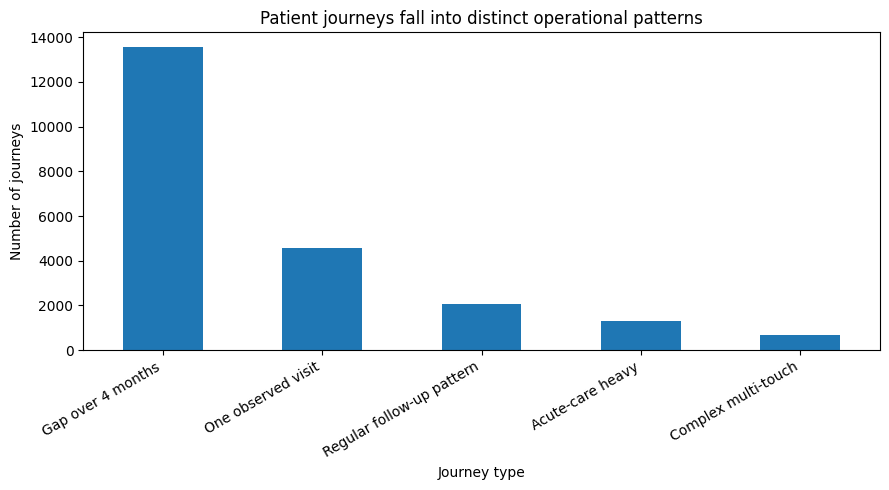

In [53]:
# SIMPLE PLOTS FOR PRESENTATION

import matplotlib.pyplot as plt

# Bar chart: journey type distribution
journey_counts = journey_table["journey_type"].value_counts()

plt.figure(figsize=(9, 5))
journey_counts.plot(kind="bar")
plt.title("Patient journeys fall into distinct operational patterns")
plt.xlabel("Journey type")
plt.ylabel("Number of journeys")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


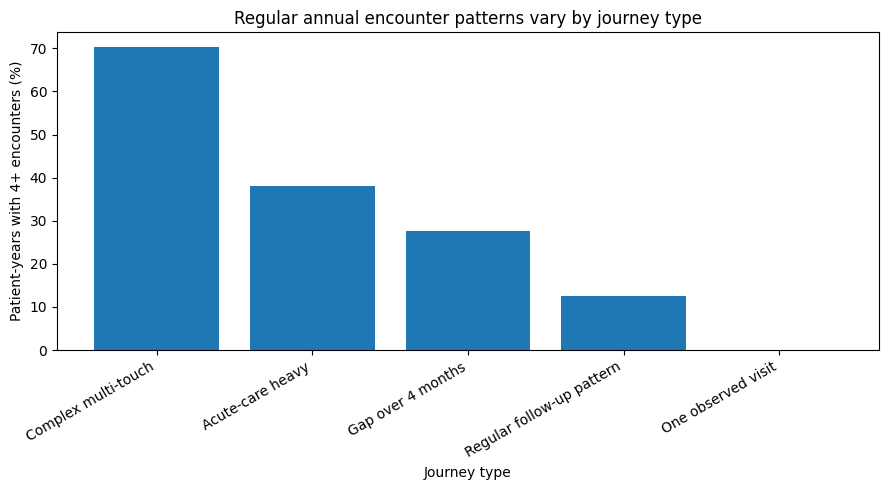

In [ ]:
# Bar chart: 4+ annual encounter rate by journey type
plot_df = journey_type_summary.sort_values("regular_checkup_4plus_rate", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["journey_type"], plot_df["regular_checkup_4plus_rate"])
plt.title("Regular annual encounter patterns vary by journey type")
plt.xlabel("Journey type")
plt.ylabel("Patient-years with 4+ encounters (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


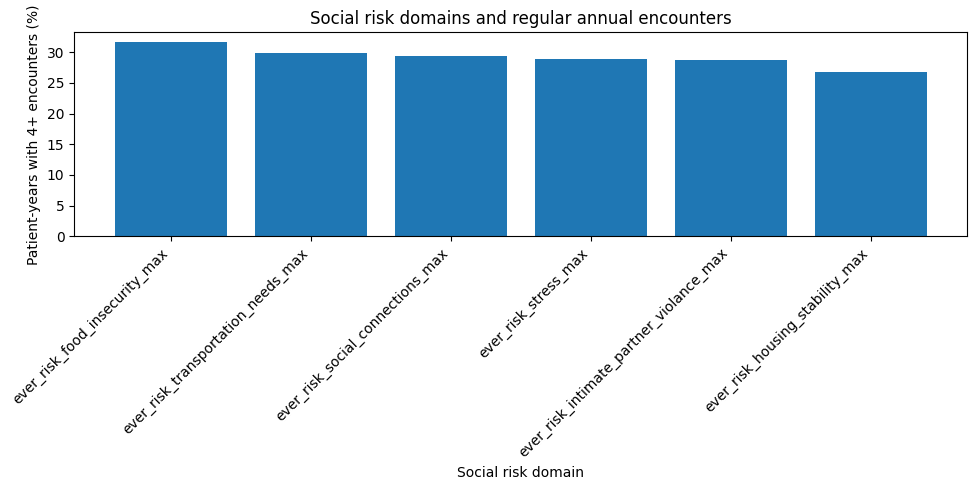

In [55]:
# If social risk summary exists, plot risk domains.
if not social_risk_summary.empty and {"risk_flag", "risk_domain", "regular_checkup_4plus_rate"}.issubset(social_risk_summary.columns):
    
    # Focus on risk_flag == 1.
    risk_plot = social_risk_summary[
        social_risk_summary["risk_flag"] == 1
    ].copy()
    
    if not risk_plot.empty:
        risk_plot = risk_plot.sort_values("regular_checkup_4plus_rate", ascending=False).head(10)
        
        plt.figure(figsize=(10, 5))
        plt.bar(risk_plot["risk_domain"], risk_plot["regular_checkup_4plus_rate"])
        plt.title("Social risk domains and regular annual encounters")
        plt.xlabel("Social risk domain")
        plt.ylabel("Patient-years with 4+ encounters (%)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No rows with risk_flag == 1 to plot yet. Check social risk rules and answers.")
else:
    print("Social risk summary is empty or missing required columns.")
